# Hai bài thực nghiệm transfer learning cho ảnh cảnh tự nhiên

Notebook dùng đủ sáu lớp **buildings, forest, glacier, mountain, sea, street** của
[Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification).
Phần dữ liệu và các hàm hỗ trợ dùng chung. **Phần 7 là MobileNetV3-Small; phần 8 là ViT-B/16**.
Sau phần chuẩn bị, có thể chạy riêng một phần hoặc chạy lần lượt cả hai.
Mỗi phần tự khởi tạo, huấn luyện, đánh giá và trình bày kết luận của chính mô hình đó.

Mỗi bài thực nghiệm trả lời hai câu hỏi:

1. **Fine-tuning backbone có cải thiện validation so với chỉ huấn luyện classifier không?**
2. **Checkpoint cuối phân loại ảnh test tốt đến đâu, và còn nhầm ở những lớp nào?**

Số liệu đối chiếu là giữa **hai giai đoạn của cùng một mô hình**, và giữa **dự đoán với nhãn thật**.
Các kết luận, caption và bảng metrics được tính từ lần chạy thực tế.

**Cách chạy trên Colab/Kaggle:** bật GPU và Internet; chạy các phần 1–6; chạy phần 7 và/hoặc 8;
sau đó chạy phần 9–11. Mặc định chạy toàn bộ dữ liệu, seed 42, 3 epoch classifier và tối đa 15 epoch fine-tuning.
Đặt `cfg.smoke_test = True` trước khi tạo các biến cấu hình runtime để kiểm tra nhanh.
Smoke test có đủ sáu lớp, 1 epoch mỗi giai đoạn; chỉ kiểm chứng luồng xử lý, không chứng minh chất lượng mô hình.
EDA vẫn kiểm tra toàn bộ train/test trước khi lấy subset smoke để phát hiện rò rỉ ảnh trùng.

Checkpoint/cache được lưu để tiếp tục huấn luyện; trên Colab có thể đặt `output_dir` trong Drive sau khi mount.
Phần 11 **chỉ in ra console**, không tạo file kết luận. Mọi code cell có markdown giải thích ngay phía trước.


## 1. Thư viện và cấu hình

### 1.1. Kiểm tra thư viện

**Mục đích:** Chuẩn bị thư viện xử lý ảnh, EDA và transfer learning trong một notebook độc lập.

**Đầu vào và phụ thuộc:** Python của runtime Colab/Kaggle; cần Internet ở lần cài/tải dữ liệu đầu tiên.

**Cách hoạt động:** Kiểm tra module đã có trước khi dùng pip. Giữ cặp PyTorch/Torchvision GPU có sẵn; chỉ cài cặp này nếu còn thiếu. Các thư viện còn thiếu được cài vào đúng Python của kernel.

**Đầu ra:** Thư viện có thể import ở cell tiếp theo.

**Cách đọc và sử dụng:** Nếu runtime yêu cầu restart sau khi cài, restart rồi chạy lại từ đầu. Cell không tự bật GPU; chọn GPU trong thiết lập Colab/Kaggle.


In [1]:
import importlib.util
import subprocess
import sys

if not all(importlib.util.find_spec(name) for name in ('torch', 'torchvision')):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch>=2.5,<3', 'torchvision>=0.20,<1'])
required = {
    'datasets': 'datasets>=3,<6', 'kagglehub': 'kagglehub>=0.3.12,<1',
    'numpy': 'numpy>=1.26,<3', 'pandas': 'pandas>=2.2,<4',
    'matplotlib': 'matplotlib>=3.8,<4', 'seaborn': 'seaborn>=0.13,<1',
    'sklearn': 'scikit-learn>=1.5,<2',
    'cv2': 'opencv-python-headless>=4.10,<5', 'PIL': 'Pillow>=10,<13',
    'tqdm': 'tqdm>=4.66,<5',
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])


### 1.2. Import các nhóm công cụ

**Mục đích:** Đưa các công cụ cần thiết vào namespace của notebook.

**Đầu vào và phụ thuộc:** Cell cài đặt đã chạy thành công.

**Cách hoạt động:** PIL/OpenCV đọc và đo chất lượng ảnh; NumPy/Pandas xử lý bảng; Matplotlib/Seaborn vẽ; KaggleHub tải dữ liệu; thư viện datasets nạp ảnh cục bộ; PyTorch/Torchvision xây mô hình; scikit-learn chỉ tính metrics và chia tập.

**Đầu ra:** Các tên module, class và hàm dùng trong các cell sau. tqdm dùng progress bar dạng text để giảm tương tác giữa widget notebook và vòng đời worker DataLoader.

**Cách đọc và sử dụng:** Cell này chưa tải dữ liệu, chưa xây mô hình và chưa huấn luyện. Lỗi import cần được giải quyết trước khi tiếp tục.


In [2]:
import gc
import hashlib
import io
import json
import math
import os
import platform
import random
import time
import textwrap
from contextlib import contextmanager, nullcontext
from dataclasses import asdict, dataclass
from importlib.metadata import version
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from datasets import Image as HFImage, load_dataset
import kagglehub
from IPython.display import display
from PIL import Image, ImageOps
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split
from threadpoolctl import threadpool_info, threadpool_limits
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm  # progress bar dạng text để tránh backend widget trong notebook


### 1.3. Các tham số thí nghiệm

**Mục đích:** Tập trung các lựa chọn để thay đổi thí nghiệm mà không sửa vòng train.

**Đầu vào và phụ thuộc:** dataset_id là handle Kaggle owner/dataset; dataset_version=None lấy bản mới nhất, hoặc đặt số version để tái lập nguồn. Không cần dữ liệu; các giá trị mặc định phù hợp một GPU Colab/Kaggle khoảng 16 GB VRAM.

**Cách hoạt động:** Seed cố định các nguồn ngẫu nhiên. Batch size 16 và tích lũy 2 bước tạo effective batch 32 ở window đầy. Head learning rate 1e-3 giúp classifier mới học; fine-tuning dùng backbone LR 1e-5 và head LR 1e-4 để cập nhật nhẹ kiến thức pretrained. Weight decay 1e-4 điều chuẩn trọng số. Patience 4 đếm epoch fine-tuning không tăng validation macro-F1.

**Đầu ra:** Class `Config` và instance `cfg`.

**Cách đọc và sử dụng:** Sửa instance tại đây trước khi chạy cell runtime. Khi thiếu VRAM có thể dùng batch 8/accumulation 4. Đổi recipe phải chọn thư mục mới; checkpoint cũ của phiên bản notebook trước không tương thích recipe chuyển giai đoạn mới.


In [3]:
@dataclass
class Config:
    dataset_id: str = 'puneet6060/intel-image-classification'
    dataset_version: int | None = None  # None: bản mới nhất; đặt số version để cố định nguồn
    seed: int = 42
    smoke_test: bool = False
    smoke_train_per_class: int = 8
    smoke_val_per_class: int = 2
    smoke_test_per_class: int = 2
    val_fraction: float = 0.20
    batch_size: int = 16
    accumulation_steps: int = 2
    num_workers: int = 2  # giữ hai worker; iterator được đóng rõ ràng ở cuối mỗi lượt đọc
    head_epochs: int = 3
    finetune_epochs: int = 15
    head_lr: float = 1e-3
    backbone_lr: float = 1e-5
    finetune_head_lr: float = 1e-4
    weight_decay: float = 1e-4
    patience: int = 4
    resume: bool = False  # True: đọc last.pt trong cùng thư mục/config
    use_amp: bool = True
    cache_dir: str = './intel_cache'
    output_dir: str = './intel_transfer_results'
    cpu_threads: int = 2


cfg = Config()
# cfg.smoke_test = True
# cfg.output_dir = '/kaggle/working/intel_transfer_results'
# cfg.resume = True  # cần giữ cả best_head.pt, best_finetune.pt và last.pt


### 1.4. Khởi tạo runtime, seed và thư mục

**Mục đích:** Thiết lập thiết bị, tính tái lập và nơi lưu artifact cho lần chạy hiện tại.

**Đầu vào và phụ thuộc:** `cfg` từ cell trước; PyTorch tự kiểm tra CUDA.

**Cách hoạt động:** Chọn CUDA khi có, bật AMP chỉ với CUDA, giới hạn CPU threads cho PyTorch/OpenCV/BLAS. Hàm seed thiết lập Python/NumPy/PyTorch. Đặt KAGGLEHUB_CACHE trong cfg.cache_dir cho dữ liệu tải từ Kaggle. Các hàm lưu JSON/figure dùng chung; caption được in ngay dưới biểu đồ. Tạo registry `model_results` rỗng để hai phần độc lập có thể đăng ký kết quả.

**Đầu ra:** `device`, `ROOT`, `CACHE`, registry kết quả, `config.json` và `environment.json`.

**Cách đọc và sử dụng:** Hai chế độ smoke/full dùng thư mục con khác nhau. Chạy lại cell này sẽ xóa registry trong RAM; cần chạy lại phần mô hình muốn tổng kết. Không có CUDA thì có thể smoke trên CPU, còn full ViT sẽ chậm.


In [4]:
assert 0 < cfg.val_fraction < 1 and cfg.batch_size > 0 and cfg.accumulation_steps > 0
assert cfg.head_epochs > 0 and cfg.finetune_epochs > 0 and cfg.cpu_threads > 0
assert cfg.dataset_version is None or (isinstance(cfg.dataset_version, int) and cfg.dataset_version > 0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = cfg.use_amp and device.type == 'cuda'
torch.set_num_threads(cfg.cpu_threads)
cv2.setNumThreads(cfg.cpu_threads)
cpu_thread_limit = threadpool_limits(limits=cfg.cpu_threads)
ROOT = Path(cfg.output_dir) / ('smoke' if cfg.smoke_test else 'full')
CACHE = Path(cfg.cache_dir)
for directory in (ROOT, ROOT / 'figures', CACHE):
    directory.mkdir(parents=True, exist_ok=True)
# KaggleHub dùng cache này ngoài Kaggle; trong Kaggle có thể trả thư mục input được gắn sẵn.
os.environ['KAGGLEHUB_CACHE'] = str((CACHE / 'kagglehub').resolve())
torch.hub.set_dir(str(CACHE / 'torch'))
sns.set_theme(style='whitegrid')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def write_json(path, value):
    Path(path).write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')

def save_figure(name, caption=None):
    if cfg.smoke_test:
        plt.gcf().suptitle('SMOKE TEST — kết quả mô hình chỉ để kiểm chứng kỹ thuật', fontsize=11)
    figure = plt.gcf()
    if caption:
        wrapped_caption = textwrap.fill(caption, width=110)
        lines = wrapped_caption.count('\n') + 1
        bottom = min(0.30, 0.05 + lines * 0.14 / figure.get_figheight())
        figure.tight_layout(rect=(0, bottom, 1, 1))
        figure.text(0.5, 0.01, wrapped_caption, ha='center', va='bottom', fontsize=9)
    else:
        figure.tight_layout()
    plt.savefig(ROOT / 'figures' / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()
    if caption:
        print('Caption:', caption)

seed_everything(cfg.seed)
model_results = {}  # chỉ đăng ký mô hình thực sự đã được chạy
environment = {
    'python': sys.version, 'platform': platform.platform(), 'device': str(device),
    'gpu': torch.cuda.get_device_name(0) if device.type == 'cuda' else None,
    'cuda': torch.version.cuda, 'cpu_threads': torch.get_num_threads(),
    'packages': {name: version(name) for name in (
        'torch', 'torchvision', 'datasets', 'kagglehub', 'numpy', 'pandas',
        'matplotlib', 'seaborn', 'scikit-learn', 'Pillow')},
    'dataloader': {'num_workers': cfg.num_workers, 'persistent_workers': False,
                   'iterator_cleanup': 'owner_process_finally', 'progress_backend': 'tqdm.text'},
    'opencv': cv2.__version__,
    'opencv_threads': cv2.getNumThreads(), 'native_threadpools': threadpool_info(),
}
write_json(ROOT / 'environment.json', environment)
write_json(ROOT / 'config.json', asdict(cfg))
print('Thiết bị:', device, '| chế độ:', 'SMOKE TEST' if cfg.smoke_test else 'FULL')
if device.type == 'cpu':
    print('Không có CUDA: full ViT sẽ chậm. Có thể bật cfg.smoke_test để kiểm chứng pipeline.')


Thiết bị: cuda | chế độ: FULL


## 2. Dữ liệu và kiểm tra chất lượng

### 2.1. Tải toàn bộ dataset Kaggle rồi nạp train/test cục bộ

**Mục đích:** Lấy dữ liệu từ [Intel Image Classification trên Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification), tải toàn bộ trước khi EDA/huấn luyện và nạp đủ sáu lớp.

**Đầu vào và phụ thuộc:** `cfg.dataset_id`, `cfg.dataset_version`, `CACHE` và KaggleHub. Cần Internet và dung lượng đĩa ở lần tải đầu ngoài Kaggle.

**Cách hoạt động:** Gọi `kagglehub.dataset_download(handle)` cho toàn bộ dataset, không chỉ định từng ảnh. Ngoài Kaggle, thư viện tải và giải nén dữ liệu vào cache; trong Kaggle có thể gắn dữ liệu làm input. Nếu có dataset_version, handle dùng `/versions/N`; nếu không, lấy bản mới nhất và ghi version từ đường dẫn cache khi xác định được. Tìm thư mục seg_train/seg_test/seg_pred kể cả cấu trúc lồng như seg_train/seg_train, tránh đếm lặp. Chỉ đường dẫn ảnh train/test cục bộ được truyền vào ImageFolder. Prediction được ghi số lượng nhưng không dùng trong bài thực nghiệm có giám sát.

**Đầu ra:** `dataset_dir`, `raw`, `class_names`, `LABELS`, `NUM_CLASSES`, `resolved_dataset_version` và dataset_source.json với nguồn Kaggle, version, đường dẫn và số ảnh thực tế.

**Cách đọc và sử dụng:** Theo dõi tiến trình tải/giải nén trước bảng train/test. Giữ cfg.cache_dir để tận dụng cache lần sau. Nếu môi trường yêu cầu đăng nhập Kaggle, chạy `kagglehub.login()` rồi chạy lại cell; không ghi token vào notebook. Khi input gắn sẵn không cho biết version và cấu hình chưa cố định version, metadata ghi null, không đoán version; manifest hash pixel vẫn nhận diện dữ liệu thực tế. Test chỉ dùng đánh giá cuối. API tham khảo: [KaggleHub](https://github.com/Kaggle/kagglehub#download-dataset).


In [5]:
dataset_handle = cfg.dataset_id
if cfg.dataset_version is not None:
    dataset_handle = f'{dataset_handle}/versions/{cfg.dataset_version}'
print('Nguồn Kaggle:', dataset_handle)
print('Tải/gắn toàn bộ dataset; chỉ nạp train/test sau khi dữ liệu đã sẵn sàng.')
dataset_dir = Path(kagglehub.dataset_download(dataset_handle)).resolve()
print('Thư mục dữ liệu cục bộ:', dataset_dir)

resolved_dataset_version = cfg.dataset_version
# Cache ngoài Kaggle thường kết thúc bằng /versions/N.
# Một số input trên Kaggle dùng /datasets/owner/slug/N.
version_in_path = None
if dataset_dir.name.isdecimal() and dataset_dir.parent.name in ('versions', cfg.dataset_id.rsplit('/', 1)[-1]):
    version_in_path = int(dataset_dir.name)
if version_in_path is not None:
    if cfg.dataset_version is not None and cfg.dataset_version != version_in_path:
        raise RuntimeError('Version trong đường dẫn dữ liệu khác version được yêu cầu.')
    resolved_dataset_version = version_in_path
print('Version:', resolved_dataset_version if resolved_dataset_version is not None else 'không xác định từ input; xem manifest dữ liệu')

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
def files_in(folder):
    roots = {p for p in dataset_dir.rglob(folder) if p.is_dir()}
    if dataset_dir.name == folder:
        roots.add(dataset_dir)
    # seg_train/seg_train: chỉ quét root ngoài cùng để không đếm ảnh hai lần.
    outer_roots = [root for root in roots if not any(parent in roots for parent in root.parents)]
    return sorted({
        p.relative_to(dataset_dir).as_posix()
        for root in outer_roots for p in root.rglob('*')
        if p.is_file() and p.suffix.lower() in image_extensions
    })

train_files, test_files, prediction_files = (files_in(folder) for folder in ('seg_train', 'seg_test', 'seg_pred'))
if not train_files or not test_files:
    raise RuntimeError('Không tìm thấy ảnh trong seg_train/seg_test dưới thư mục Kaggle đã tải.')
data_files = {
    split: [str(dataset_dir / p) for p in files]
    for split, files in (('train', train_files), ('test', test_files))
}
raw = load_dataset('imagefolder', data_files=data_files, cache_dir=str(CACHE / 'datasets'))
class_names = list(raw['train'].features['label'].names)
expected_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
assert class_names == expected_names, f'Nhãn ngoài dự kiến: {class_names}'
assert list(raw['test'].features['label'].names) == class_names
NUM_CLASSES = len(class_names)
LABELS = list(range(NUM_CLASSES))
raw = {split: ds.cast_column('image', HFImage(decode=False)) for split, ds in raw.items()}
source_info = {
    'provider': 'kaggle', 'dataset_id': cfg.dataset_id,
    'dataset_url': f'https://www.kaggle.com/datasets/{cfg.dataset_id}',
    'requested_handle': dataset_handle, 'requested_version': cfg.dataset_version,
    'resolved_version': resolved_dataset_version, 'class_names': class_names,
    'download_method': 'kagglehub.dataset_download (entire dataset)',
    'local_dataset_dir': str(dataset_dir),
    'loaded_splits': {split: len(ds) for split, ds in raw.items()},
    'prediction_files_available': len(prediction_files),
    'fingerprints': {split: ds._fingerprint for split, ds in raw.items()},
    'test_policy': 'Giữ mọi ảnh test có nhãn hợp lệ và decode được; không deduplicate test.',
}
write_json(ROOT / 'dataset_source.json', source_info)
display(pd.DataFrame([{'split': k, 'images': v} for k, v in source_info['loaded_splits'].items()]))
print('Ảnh prediction trong dataset:', len(prediction_files), '(không dùng cho thí nghiệm có giám sát)')


Nguồn Kaggle: puneet6060/intel-image-classification
Tải/gắn toàn bộ dataset; chỉ nạp train/test sau khi dữ liệu đã sẵn sàng.
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Thư mục dữ liệu cục bộ: /kaggle/input/intel-image-classification
Version: không xác định từ input; xem manifest dữ liệu


Resolving data files:   0%|          | 0/14034 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/3000 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

,split,images
0,train,14034
1,test,3000


Ảnh prediction trong dataset: 7301 (không dùng cho thí nghiệm có giám sát)


### 2.2. Đọc ảnh an toàn và tạo hash pixel

**Mục đích:** Thống nhất cách đọc ảnh giữa EDA, kiểm tra trùng và huấn luyện.

**Đầu vào và phụ thuộc:** Một record có bytes/path hoặc một dòng chứa source_split và row_index.

**Cách hoạt động:** PIL giải mã toàn bộ ảnh, sửa orientation EXIF, giữ thông tin mode gốc rồi chuyển RGB. Hash SHA-256 gồm kích thước và pixel RGB, nên bản sao có cùng nội dung pixel được nhận diện dù tên file khác nhau.

**Đầu ra:** Ba hàm đọc ảnh, đọc theo manifest và tính hash; chưa quét dữ liệu.

**Cách đọc và sử dụng:** RGB có ba kênh phù hợp pretrained models. Hash chính xác không phát hiện mọi ảnh crop, resize hoặc near-duplicate; phần kiểm tra thủ công vẫn cần thiết.


In [6]:
def decode_image(record):
    payload = record['image']
    source = io.BytesIO(payload['bytes']) if payload.get('bytes') is not None else payload['path']
    with Image.open(source) as image:
        image.load()
        # Sửa orientation từ EXIF trước khi tính hash và mọi phép biến đổi khác.
        oriented = ImageOps.exif_transpose(image)
        original_mode = oriented.mode
        rgb = oriented.convert('RGB').copy()
    return rgb, original_mode


def image_from_row(row):
    return decode_image(raw[row['source_split']][int(row['row_index'])])[0]


def pixel_hash(image):
    digest = hashlib.sha256()
    digest.update(np.asarray(image.size, dtype=np.int64).tobytes())
    digest.update(image.tobytes())
    return digest.hexdigest()


### 2.3. Audit từng ảnh

**Mục đích:** Phát hiện ảnh hỏng, nhãn không hợp lệ và thu thập đặc tính ảnh trước train.

**Đầu vào và phụ thuộc:** `raw` và các hàm đọc/hash ở cell trước.

**Cách hoạt động:** Duyệt từng ảnh, bắt lỗi decode thay vì dừng cả lượt quét. Đo chiều rộng/cao, aspect ratio, brightness trung bình grayscale, contrast là độ lệch chuẩn grayscale và variance of Laplacian. Nhãn hợp lệ phải thuộc 0–5.

**Đầu ra:** `audit`, `valid`, `excluded_invalid`; lưu bảng image_audit.csv và invalid_images.csv; in thống kê theo split.

**Cách đọc và sử dụng:** decode_ok và label_valid quyết định ảnh có dùng được không. Brightness/contrast/Laplacian chỉ là bằng chứng mô tả: ảnh biển ít texture có thể có Laplacian thấp dù không bị mờ.


In [7]:
def audit_dataset(datasets):
    records = []
    for split, ds in datasets.items():
        for index in tqdm(range(len(ds)), desc=f'Kiểm tra {split}'):
            result = {'sample_id': f'{split}:{index}', 'source_split': split, 'row_index': index,
                      'label': -1, 'label_valid': False, 'decode_ok': False, 'error': ''}
            try:
                record = ds[index]
                label = record.get('label')
                valid = isinstance(label, (int, np.integer)) and 0 <= int(label) < NUM_CLASSES
                result.update(label=int(label) if valid else -1, label_valid=bool(valid))
                image, mode = decode_image(record)
                gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
                width, height = image.size
                result.update(decode_ok=True, width=width, height=height, aspect_ratio=width / height,
                              mode=mode, brightness=float(gray.mean()), contrast=float(gray.std()),
                              laplacian_var=float(cv2.Laplacian(gray, cv2.CV_64F).var()),
                              rgb_hash=pixel_hash(image))
            except Exception as exc:
                result['error'] = f'{type(exc).__name__}: {exc}'
            records.append(result)
    return pd.DataFrame(records)

audit = audit_dataset(raw)
audit.to_csv(ROOT / 'image_audit.csv', index=False)
valid = audit.loc[audit.decode_ok & audit.label_valid].copy()
valid['class_name'] = valid.label.map(dict(enumerate(class_names)))
excluded_invalid = audit.loc[~(audit.decode_ok & audit.label_valid)].copy()
excluded_invalid.to_csv(ROOT / 'invalid_images.csv', index=False)
display(audit.groupby('source_split').agg(total=('sample_id', 'size'),
                                        decodable=('decode_ok', 'sum'), valid_labels=('label_valid', 'sum')))
display(excluded_invalid.head(10))


Kiểm tra train:   0%|          | 0/14034 [00:00<?, ?it/s]

Kiểm tra test:   0%|          | 0/3000 [00:00<?, ?it/s]

,total,decodable,valid_labels
source_split,,,
test,3000,3000,3000
train,14034,14034,14034


,sample_id,source_split,row_index,label,label_valid,decode_ok,error,width,height,aspect_ratio,mode,brightness,contrast,laplacian_var,rgb_hash


## 3. EDA và gợi ý preprocessing

### 3.1. Số ảnh từng lớp và ví dụ

**Mục đích:** Hiểu phân bố lớp và nội dung bài toán trước khi chọn cách xử lý ảnh.

**Đầu vào và phụ thuộc:** `valid` chứa ảnh decode được, nhãn hợp lệ và tên lớp.

**Cách hoạt động:** Tạo bảng lớp × split và biểu đồ cột; chọn ngẫu nhiên có seed một ảnh train mỗi lớp. Hiển thị ảnh cùng kích thước để quan sát cảnh tự nhiên và sự đa dạng.

**Đầu ra:** Bảng class_counts_raw.csv, biểu đồ số ảnh và lưới sáu ảnh mẫu.

**Cách đọc và sử dụng:** Lớp có ít ảnh có thể học kém hơn; cần xem macro-F1 thay vì chỉ accuracy. Lưới ảnh giúp nhận ra bối cảnh dễ nhầm như glacier/mountain hoặc buildings/street; chưa đủ để kết luận nhãn sai.


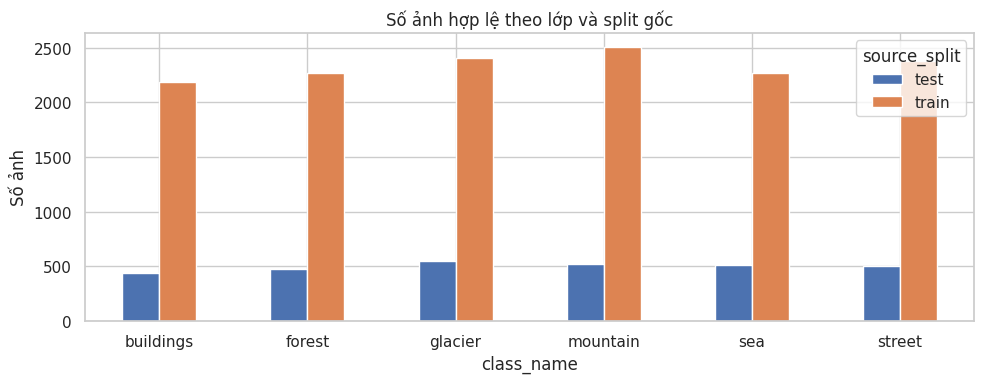

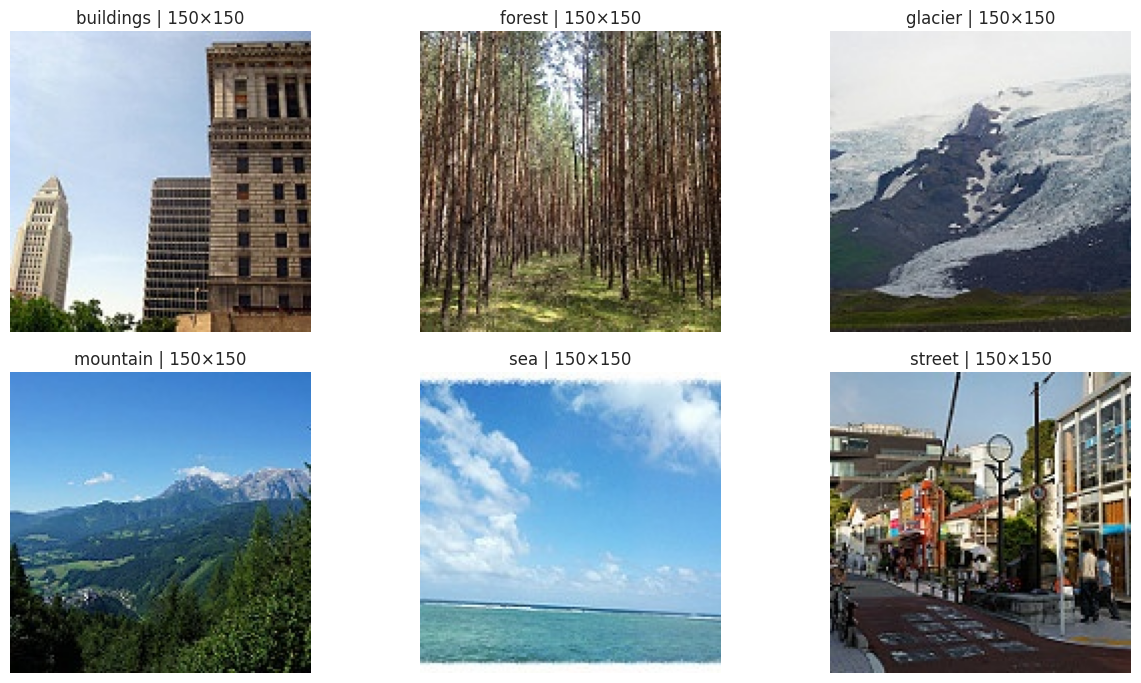

In [8]:
counts = pd.crosstab(valid.class_name, valid.source_split).reindex(class_names, fill_value=0)
counts.to_csv(ROOT / 'class_counts_raw.csv')
counts.plot.bar(figsize=(10, 4), rot=0)
plt.title('Số ảnh hợp lệ theo lớp và split gốc')
plt.ylabel('Số ảnh')
save_figure('eda_class_counts')

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for label, ax in enumerate(axes.flat):
    rows = valid[(valid.source_split == 'train') & (valid.label == label)]
    if len(rows):
        row = rows.sample(1, random_state=cfg.seed).iloc[0]
        ax.imshow(image_from_row(row))
        ax.set_title(f'{class_names[label]} | {row.width:.0f}×{row.height:.0f}')
    ax.axis('off')
save_figure('eda_samples')


### 3.2. Kích thước, màu và chất lượng ảnh

**Mục đích:** Tìm các trường hợp cần xem xét preprocessing bằng bằng chứng trực quan.

**Đầu vào và phụ thuộc:** `valid`, `image_from_row()` và công cụ plotting.

**Cách hoạt động:** Vẽ histogram theo split cho kích thước, aspect ratio, độ sáng, tương phản và log(1+Laplacian variance); vẽ phân bố mode. Hiển thị ảnh train ở các cực trị để kiểm tra bằng mắt.

**Đầu ra:** Biểu đồ phân bố, bảng describe và ảnh tối/sáng/ít cạnh/tỷ lệ khung hình bất thường.

**Cách đọc và sử dụng:** Dùng phần phát triển để quyết định preprocessing. Kiểm tra test ở đây chỉ phục vụ cấu trúc, chất lượng và chống rò rỉ. Không tự loại ảnh tối/ít cạnh; upsample lên 224 không tạo thêm chi tiết ảnh gốc.


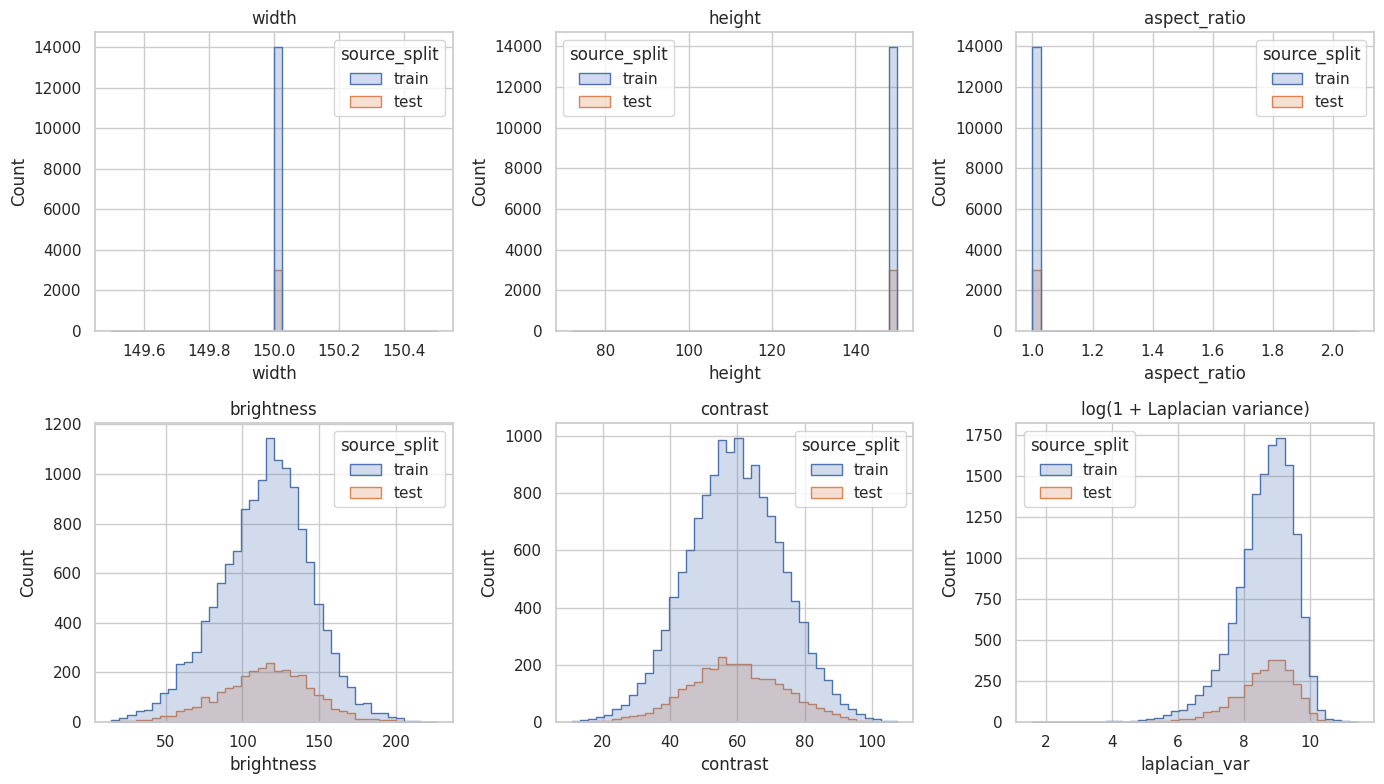

,source_split,mode,count
0,test,RGB,3000
1,train,RGB,14034


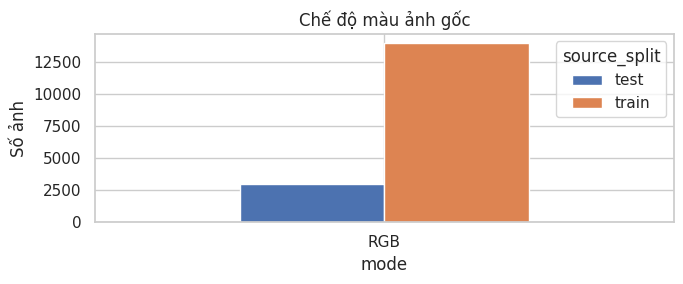

width                                                  height  \
                count   mean  std    min    25%    50%    75%    max    count   
source_split                                                                    
test           3000.0  150.0  0.0  150.0  150.0  150.0  150.0  150.0   3000.0   
train         14034.0  150.0  0.0  150.0  150.0  150.0  150.0  150.0  14034.0   

                          ...   contrast             laplacian_var  \
                    mean  ...        75%         max         count   
source_split              ...                                        
test          149.903333  ...  69.145764  103.267296        3000.0   
train         149.908722  ...  68.701153  107.383298       14034.0   

                                                                             \
                     mean          std        min          25%          50%   
source_split                                                                  
test          7739.187916  6070.876137   3.891326  3484.745730  6466.418275   
train         7773.305832  5878.586898  10.767131  3495.742909  6465.652355   

                                          
                       75%           max  
source_split                              
test          10528.104793  95228.143008  
train         10681.596548  77314.862688  

[2 rows x 40 columns]

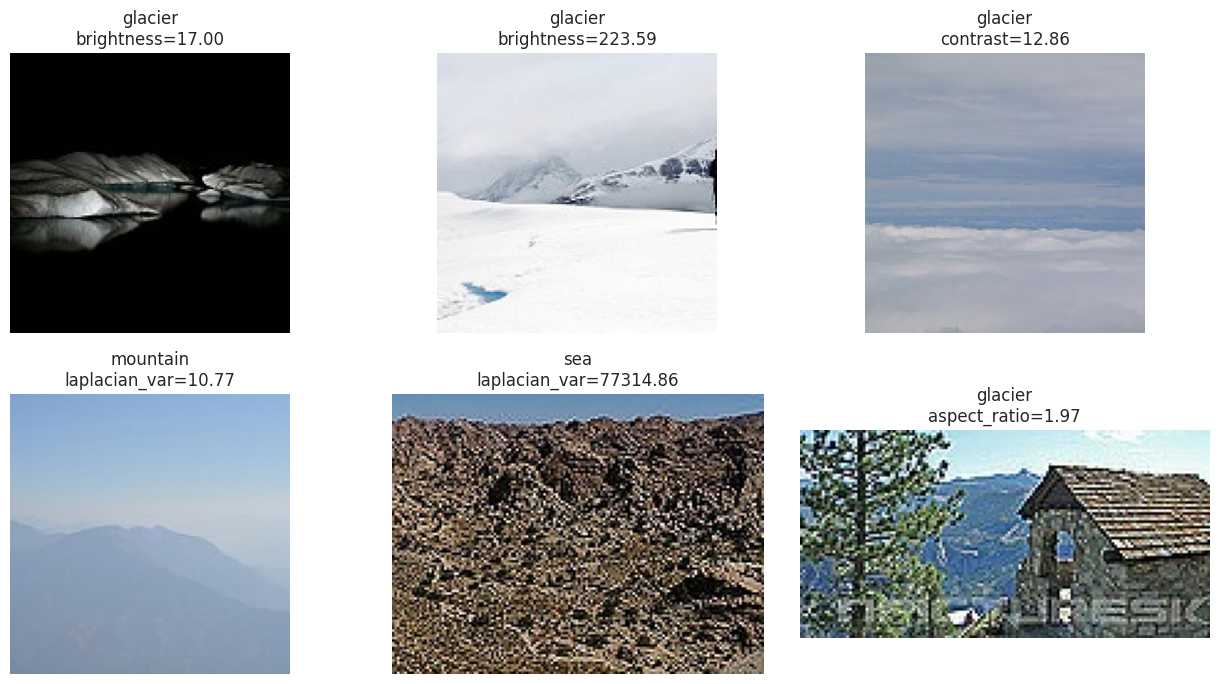

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, column in zip(axes.flat, ['width', 'height', 'aspect_ratio', 'brightness', 'contrast', 'laplacian_var']):
    data = valid.copy()
    if column == 'laplacian_var':
        data[column] = np.log1p(data[column])
    sns.histplot(data=data, x=column, hue='source_split', bins=40, element='step', ax=ax)
    ax.set_title('log(1 + Laplacian variance)' if column == 'laplacian_var' else column)
save_figure('eda_distributions')
display(valid.groupby(['source_split', 'mode']).size().rename('count').reset_index())
pd.crosstab(valid['mode'], valid.source_split).plot.bar(figsize=(7, 3), rot=0)
plt.title('Chế độ màu ảnh gốc')
plt.ylabel('Số ảnh')
save_figure('eda_color_modes')
display(valid.groupby('source_split')[['width', 'height', 'brightness', 'contrast', 'laplacian_var']].describe())

# Hiển thị mẫu ở các cực trị của tập phát triển để kiểm tra bằng mắt.
train_audit = valid[valid.source_split == 'train']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (column, smallest) in zip(axes.flat, [
    ('brightness', True), ('brightness', False), ('contrast', True),
    ('laplacian_var', True), ('laplacian_var', False), ('aspect_ratio', False)]):
    rows = train_audit.sort_values(column, ascending=smallest)
    if len(rows):
        row = rows.iloc[0]
        ax.imshow(image_from_row(row))
        ax.set_title(f'{row.class_name}\n{column}={row[column]:.2f}')
    ax.axis('off')
save_figure('eda_extreme_examples')


## 4. Làm sạch và chia tập

### 4.1. Xem các nhóm ảnh trùng

**Mục đích:** Tìm các ảnh trùng chính xác, bao gồm trùng xuyên train/test và nhóm nhãn khác nhau.

**Đầu vào và phụ thuộc:** `valid` và rgb_hash của từng ảnh.

**Cách hoạt động:** Nhóm hash xuất hiện nhiều lần, thống kê số ảnh, số nhãn và các split liên quan; hiển thị một nhóm làm ví dụ.

**Đầu ra:** duplicates.csv, bảng nhóm trùng và ảnh minh họa nếu có.

**Cách đọc và sử dụng:** Một hash có nhiều nhãn là dấu hiệu cần kiểm tra thủ công, không tự đổi nhãn. Ảnh train trùng test cần bị loại khỏi tập phát triển trước khi tách validation.


,rgb_hash,count,labels,source_splits
0,0dc697eda3e051d80a1c62d61c589425b5b4fb7753b864...,2,2,train
1,37dc7d511558c1120eefed746ea983dac659f37df4d5be...,2,2,train
2,3e5fe1e79ef067b988d05cad113a32590c0966463eeeab...,2,1,train
3,3e8b8707b57f39fcb849ca6cfc6bc6623878f61c6caf74...,2,2,train
4,4fea11269c231ede90b3c387da7fa3bd47e43866b9e77e...,2,1,train
5,62c5446e125bb71abb685ce64884f63ff40fb079816d6d...,2,2,train
6,710ea2ad979a9e2132e6258c16ddfe0c3c636bf5eb0386...,2,2,"test,train"
7,8a494d5a1883fe9c068dc46b5f6a2b769bbc744d9044a5...,2,2,train
8,8d5e68e44da01b473935d7c0315aafb6f902f0b75db30a...,2,2,train
9,8e3493a613419522f2222db6ab5655e9fa5a5663a22b1d...,2,1,train


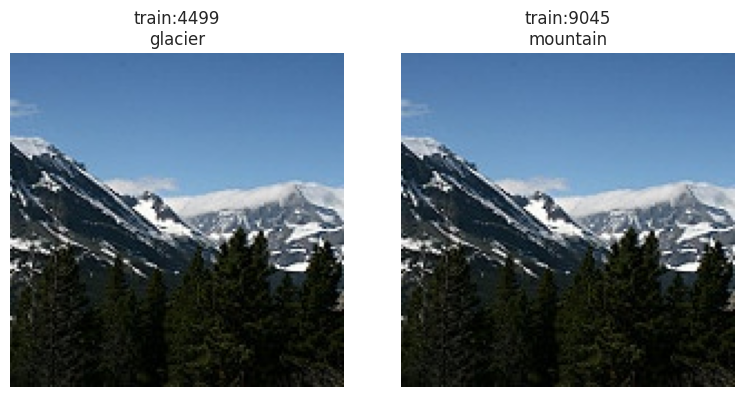

In [10]:
duplicate_rows = valid[valid.duplicated('rgb_hash', keep=False)].sort_values(['rgb_hash', 'sample_id'])
duplicate_rows.to_csv(ROOT / 'duplicates.csv', index=False)
duplicate_summary = (duplicate_rows.groupby('rgb_hash').agg(
    count=('sample_id', 'size'), labels=('label', 'nunique'),
    source_splits=('source_split', lambda values: ','.join(sorted(set(values))))).reset_index())
display(duplicate_summary.head(10))
if len(duplicate_summary):
    example_hash = duplicate_summary.iloc[0].rgb_hash
    examples = duplicate_rows[duplicate_rows.rgb_hash == example_hash].head(6)
    fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 4), squeeze=False)
    for ax, (_, row) in zip(axes.flat, examples.iterrows()):
        ax.imshow(image_from_row(row))
        ax.set_title(f'{row.sample_id}\n{row.class_name}')
        ax.axis('off')
    save_figure('eda_duplicate_examples')


### 4.2. Làm sạch, stratification và kiểm tra split

**Mục đích:** Tạo train/validation/test không rò rỉ ảnh trùng chính xác và dùng chung cho mỗi bài thực nghiệm.

**Đầu vào và phụ thuộc:** `audit`, seed, val_fraction và cấu hình smoke test.

**Cách hoạt động:** Loại ảnh decode lỗi/nhãn không hợp lệ; giữ test hợp lệ nguyên trạng. Loại train trùng test, loại nhóm train có nhãn mâu thuẫn, giữ một ảnh trong nhóm train thống nhất. Tách 20% train gốc đã làm sạch thành validation có stratification; smoke lấy ít ảnh mỗi lớp sau bước này. Assert đủ sáu lớp và không giao sample ID/hash giữa ba split.

**Đầu ra:** `splits_full`, `splits`, cleaning_log.csv, manifest đầy đủ/đang dùng và số lượng mỗi lớp.

**Cách đọc và sử dụng:** Train cập nhật trọng số; validation chọn checkpoint và early stopping; test chỉ đánh giá sau khi cố định lựa chọn. Test có thể còn bản sao nội bộ vì mục tiêu giữ split gốc; điều này được báo trong kết luận.


In [11]:
def clean_and_split(audit_frame):
    accepted = audit_frame[audit_frame.decode_ok & audit_frame.label_valid].copy()
    accepted['class_name'] = accepted.label.map(dict(enumerate(class_names)))
    test = accepted[accepted.source_split == 'test'].copy()
    train = accepted[accepted.source_split == 'train'].copy()
    test_hashes = set(test.rgb_hash)
    conflict_hashes = set(train.groupby('rgb_hash').label.nunique().loc[lambda x: x > 1].index)
    removals = []
    kept = []
    seen = set()
    for _, row in train.sort_values('row_index').iterrows():
        reason = None
        if row.rgb_hash in test_hashes:
            reason = 'train_duplicate_of_test'
        elif row.rgb_hash in conflict_hashes:
            reason = 'train_conflicting_labels'
        elif row.rgb_hash in seen:
            reason = 'train_exact_duplicate'
        if reason:
            record = row.to_dict()
            record['reason'] = reason
            removals.append(record)
        else:
            seen.add(row.rgb_hash)
            kept.append(row.to_dict())
    development = pd.DataFrame(kept)
    if development.empty or test.empty:
        raise ValueError('Không đủ dữ liệu hợp lệ sau kiểm tra chất lượng.')
    for name, frame in [('development', development), ('test', test)]:
        if set(frame.label) != set(LABELS):
            raise ValueError(f'{name} không còn đủ sáu lớp; cần kiểm tra log trước khi huấn luyện.')
    train_idx, val_idx = train_test_split(
        np.arange(len(development)), test_size=cfg.val_fraction,
        random_state=cfg.seed, stratify=development.label)
    splits = {'train': development.iloc[train_idx].copy(),
              'val': development.iloc[val_idx].copy(), 'test': test}
    return splits, pd.DataFrame(removals, columns=list(train.columns) + ['reason'])

splits_full, cleaning_log = clean_and_split(audit)
cleaning_log.to_csv(ROOT / 'cleaning_log.csv', index=False)
display(cleaning_log.groupby(['source_split', 'reason']).size().rename('count').reset_index())

def stratified_subset(frame, per_class):
    parts = []
    for label in LABELS:
        group = frame[frame.label == label]
        if len(group) < per_class:
            raise ValueError(f'Lớp {class_names[label]} chỉ có {len(group)} ảnh, cần {per_class} cho smoke test.')
        parts.append(group.sample(per_class, random_state=cfg.seed + label))
    return pd.concat(parts).sort_values('sample_id').reset_index(drop=True)

splits = {name: frame.reset_index(drop=True) for name, frame in splits_full.items()}
if cfg.smoke_test:
    splits = {name: stratified_subset(splits[name], size) for name, size in [
        ('train', cfg.smoke_train_per_class), ('val', cfg.smoke_val_per_class),
        ('test', cfg.smoke_test_per_class)]}

def verify_splits(frames):
    for name, frame in frames.items():
        assert len(frame) > 0 and set(frame.label) == set(LABELS), name
        assert frame.sample_id.is_unique
    for left, right in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
        assert not set(frames[left].sample_id) & set(frames[right].sample_id)
        assert not set(frames[left].rgb_hash) & set(frames[right].rgb_hash)

verify_splits(splits_full)
verify_splits(splits)
manifest_full = pd.concat([frame.assign(split=name) for name, frame in splits_full.items()], ignore_index=True)
manifest = pd.concat([frame.assign(split=name) for name, frame in splits.items()], ignore_index=True)
manifest_full.to_csv(ROOT / 'split_manifest_full.csv', index=False)
manifest.to_csv(ROOT / 'split_manifest.csv', index=False)
split_counts = pd.crosstab(manifest.class_name, manifest.split).reindex(class_names)
display(split_counts)
split_counts.to_csv(ROOT / 'class_counts_used.csv')


,source_split,reason,count
0,train,train_conflicting_labels,20
1,train,train_duplicate_of_test,3
2,train,train_exact_duplicate,5


split,test,train,val
class_name,,,
buildings,437,1750,437
forest,474,1815,454
glacier,553,1918,480
mountain,525,2003,501
sea,510,1817,455
street,501,1901,475


### 4.3. Khuyến nghị dựa trên EDA và định danh thí nghiệm

**Mục đích:** Biến quan sát thành gợi ý preprocessing có căn cứ, đồng thời ngăn resume nhầm dữ liệu/recipe.

**Đầu vào và phụ thuộc:** Audit, cleaning log, tập phát triển và manifest đã kiểm tra.

**Cách hoạt động:** Tạo bảng vấn đề → bằng chứng → đề xuất: cân bằng lớp khi lệch rõ, kiểm tra ảnh tối/ít tương phản trước khi thử CLAHE, chỉ cân nhắc khử nhiễu nếu thấy nhiễu. Tính signature từ nguồn Kaggle/version, manifest và config, bao gồm quy tắc fine-tuning từ best_head.

**Đầu ra:** preprocessing_recommendations.csv, `RUN_SIGNATURE`, experiment.json và các quan sát định lượng.

**Cách đọc và sử dụng:** Khuyến nghị không tự thay đổi ảnh. Nếu thử preprocessing bổ sung, phải chọn bằng validation. Signature thay đổi khi dữ liệu/recipe thay đổi; checkpoint phải tương thích để tiếp tục.


In [12]:
recommendations = []
def recommend(problem, evidence, action):
    recommendations.append({'Vấn đề/quan sát': problem, 'Bằng chứng': evidence, 'Đề xuất': action})

if len(excluded_invalid):
    recommend('Ảnh lỗi hoặc nhãn không hợp lệ', f'{len(excluded_invalid)} ảnh; xem invalid_images.csv',
              'Loại khỏi split tương ứng và báo số lượng; không tự sửa nhãn test.')
if len(cleaning_log):
    recommend('Ảnh trùng ảnh hưởng tập phát triển', f'{len(cleaning_log)} ảnh train bị loại; xem cleaning_log.csv',
              'Làm sạch trước chia validation; kiểm tra thủ công nhóm nhãn mâu thuẫn.')
test_duplicates = int(splits_full['test'].duplicated('rgb_hash').sum())
if test_duplicates:
    recommend('Bản sao trong test', f'{test_duplicates} bản sao ngoài ảnh đầu tiên mỗi hash',
              'Giữ test gốc, ghi rõ số mẫu độc lập có thể thấp hơn số ảnh.')
dev = pd.concat([splits_full['train'], splits_full['val']], ignore_index=True)
class_count = dev.groupby('label').size().reindex(LABELS, fill_value=0)
imbalance_ratio = float(class_count.max() / class_count.min())
recommend('Độ cân bằng lớp', f'max/min={imbalance_ratio:.2f}',
          'Thử class-weight hoặc sampler chỉ trên train, chọn bằng validation.' if imbalance_ratio > 1.5
          else 'Dùng cross-entropy thường và báo macro-F1; chưa cần tự cân bằng lớp.')
non_rgb = int((dev['mode'] != 'RGB').sum())
recommend('Kích thước/chế độ màu', f'{non_rgb} ảnh không phải RGB; median={dev.width.median():.0f}×{dev.height.median():.0f}',
          'Chuyển RGB, resize/crop theo pretrained weights; upsample không tạo thêm chi tiết.')
dark = int((dev.brightness < 40).sum())
low_contrast = int((dev.contrast < 15).sum())
if dark or low_contrast:
    recommend('Ảnh tối/ít tương phản cần kiểm tra', f'{dark} ảnh brightness<40; {low_contrast} ảnh std<15',
              'Xem ảnh mẫu; có thể thử CLAHE trên train/validation như ablation nếu cải thiện; giữ pipeline gốc làm mốc.')
flat = int((dev.laplacian_var < 10).sum())
if flat:
    recommend('Ảnh ít cạnh/độ sắc nét thấp', f'{flat} ảnh Laplacian variance<10 (chỉ ngưỡng gợi ý)',
              'Kiểm tra bằng mắt. Chỉ thử khử nhiễu khi thấy nhiễu thực tế; không tự xóa ảnh biển hoặc ảnh ít texture.')
recommend('Nhãn mơ hồ và gần trùng', 'Hash pixel không phát hiện near-duplicate; độ tin cậy không xác nhận lỗi nhãn',
          'Kiểm tra thủ công các nhóm dễ nhầm và dự đoán sai; cân nhắc perceptual hash/group split trong nghiên cứu tiếp theo.')
recommendations = pd.DataFrame(recommendations)
display(recommendations)
recommendations.to_csv(ROOT / 'preprocessing_recommendations.csv', index=False)

manifest_digest = hashlib.sha256(manifest[['sample_id', 'label', 'rgb_hash', 'split']].to_csv(index=False).encode()).hexdigest()
experiment = {'config': {k: v for k, v in asdict(cfg).items() if k not in ('resume', 'output_dir', 'cache_dir')},
              'source': {'provider': 'kaggle', 'dataset_id': cfg.dataset_id, 'version': resolved_dataset_version},
              'manifest_digest': manifest_digest,
              'weights': {'mobilenet_v3_small': 'IMAGENET1K_V1', 'vit_b_16': 'IMAGENET1K_V1'},
              'pipeline_version': 3, 'finetune_start': 'best_head', 'tie_policy': 'head'}
RUN_SIGNATURE = hashlib.sha256(json.dumps(experiment, sort_keys=True).encode()).hexdigest()
write_json(ROOT / 'experiment.json', {**experiment, 'run_signature': RUN_SIGNATURE})


,Vấn đề/quan sát,Bằng chứng,Đề xuất
0,Ảnh trùng ảnh hưởng tập phát triển,28 ảnh train bị loại; xem cleaning_log.csv,Làm sạch trước chia validation; kiểm tra thủ c...
1,Độ cân bằng lớp,max/min=1.14,Dùng cross-entropy thường và báo macro-F1; chư...
2,Kích thước/chế độ màu,0 ảnh không phải RGB; median=150×150,"Chuyển RGB, resize/crop theo pretrained weight..."
3,Ảnh tối/ít tương phản cần kiểm tra,137 ảnh brightness<40; 8 ảnh std<15,Xem ảnh mẫu; có thể thử CLAHE trên train/valid...
4,Nhãn mơ hồ và gần trùng,Hash pixel không phát hiện near-duplicate; độ ...,Kiểm tra thủ công các nhóm dễ nhầm và dự đoán ...


## 5. Chuẩn bị đầu vào và mô hình

### 5.1. Pretrained weights, augmentation và Dataset

**Mục đích:** Chuẩn bị đầu vào 3×224×224 phù hợp ImageNet-pretrained weights.

**Đầu vào và phụ thuộc:** `splits`, hàm đọc RGB và Torchvision.

**Cách hoạt động:** MobileNet dùng IMAGENET1K_V1; ViT dùng IMAGENET1K_V1. Train dùng random crop diện tích 80–100%, flip ngang và color jitter nhẹ. Tensor được chuẩn hóa (x−mean)/std theo ImageNet. SceneDataset trả tensor, label và sample_id để truy vết dự đoán.

**Đầu ra:** `WEIGHTS`, hàm training_transform và class SceneDataset.

**Cách đọc và sử dụng:** Augmentation tạo biến thể chỉ khi train. Validation/test dùng weights.transforms() xác định, không augmentation. Normalize thay đổi thang số để phù hợp kiến thức pretrained, không sửa nhãn hoặc tăng độ phân giải thật của ảnh.


In [13]:
WEIGHTS = {
    'mobilenet_v3_small': models.MobileNet_V3_Small_Weights.IMAGENET1K_V1,
    'vit_b_16': models.ViT_B_16_Weights.IMAGENET1K_V1,
}

def training_transform():
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])


class SceneDataset(Dataset):
    def __init__(self, frame, transform):
        self.rows = frame.to_dict('records')
        self.transform = transform
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, index):
        row = self.rows[index]
        return self.transform(image_from_row(row)), int(row['label']), row['sample_id']


### 5.2. DataLoader, worker và vòng đời iterator

**Mục đích:** Đưa dữ liệu theo batch vào vòng train, giữ hai worker và đóng chúng trong đúng tiến trình tạo iterator để tránh lỗi can only test a child process khi dọn bộ nhớ.

**Đầu vào và phụ thuộc:** SceneDataset, splits, cfg, contextmanager và model_name. num_workers vẫn lấy nguyên giá trị từ cfg (mặc định 2).

**Cách hoạt động:** Train shuffle bằng generator riêng; seed_worker thiết lập NumPy/Python trong worker. Validation không shuffle và dùng transforms của weights. managed_loader_iterator dọn các đối tượng cũ trước khi tạo iterator, rồi dùng finally để gọi cơ chế shutdown của PyTorch trong tiến trình tạo worker, kể cả khi break, lỗi hoặc KeyboardInterrupt. Không bật persistent_workers: mỗi epoch tạo worker với seed từ generator như recipe hiện tại, tránh thay đổi trạng thái RNG worker khi resume. Make_loaders chỉ tạo train/val; test được dùng sau khi chọn checkpoint.

**Đầu ra:** Các loader train/val, generator có state lưu được trong checkpoint và context manager dùng chung cho train/evaluation.

**Cách đọc và sử dụng:** Luôn dùng iterator trong with managed_loader_iterator(loader). Số worker, batch size, accumulation và RUN_SIGNATURE giữ nguyên. Hàm _shutdown_workers là API nội bộ PyTorch, được gọi có kiểm tra vì iterator chưa có public close(); không sửa mã thư viện hay che traceback lỗi đọc ảnh. Khi cập nhật notebook trên Colab/Kaggle, giữ checkpoint, restart kernel một lần để bỏ worker cũ rồi chạy lại với cfg.resume=True và cùng cấu hình/dữ liệu/thư mục kết quả. Cơ chế shutdown tham khảo: [mã nguồn PyTorch](https://github.com/pytorch/pytorch/blob/v2.6.0/torch/utils/data/dataloader.py).


In [14]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


@contextmanager
def managed_loader_iterator(loader):
    # Dọn iterator cũ không còn được tham chiếu trong tiến trình chính trước
    # khi DataLoader tạo nhóm worker mới, để chúng không bị kế thừa qua fork.
    gc.collect()
    owner_pid = os.getpid()
    iterator = iter(loader)
    try:
        yield iterator
    finally:
        # PyTorch chưa cung cấp public close() cho DataLoader iterator.
        # Chỉ tiến trình tạo iterator được yêu cầu dừng/join các worker.
        if os.getpid() == owner_pid:
            shutdown = getattr(iterator, '_shutdown_workers', None)
            if callable(shutdown):
                shutdown()
        del iterator


def make_loaders(model_name):
    generator = torch.Generator().manual_seed(cfg.seed)
    loaders = {}
    for split in ('train', 'val'):
        transform = training_transform() if split == 'train' else WEIGHTS[model_name].transforms()
        loaders[split] = DataLoader(
            SceneDataset(splits[split], transform), batch_size=cfg.batch_size,
            shuffle=split == 'train', drop_last=False, num_workers=cfg.num_workers,
            persistent_workers=False,
            pin_memory=device.type == 'cuda', worker_init_fn=seed_worker,
            generator=generator if split == 'train' else torch.Generator().manual_seed(cfg.seed),
        )
    return loaders, generator


### 5.3. Xây classifier sáu lớp và điều khiển backbone

**Mục đích:** Chuyển model pretrained từ phân loại ImageNet sang sáu cảnh tự nhiên.

**Đầu vào và phụ thuộc:** model_name và WEIGHTS; pretrained=False dùng khi nạp checkpoint đã huấn luyện.

**Cách hoạt động:** Thay Linear cuối của MobileNet hoặc heads.head của ViT bằng Linear có sáu đầu ra. Giai đoạn head chỉ cho classifier cập nhật; backbone eval giữ BatchNorm running stats và tắt dropout của backbone. Fine-tuning mở toàn bộ parameter và bật train mode.

**Đầu ra:** Các hàm xây model, xác định classifier, cấu hình requires_grad và train/eval mode.

**Cách đọc và sử dụng:** Backbone là phần trích đặc trưng đã học; classifier ánh xạ đặc trưng thành sáu logits. requires_grad=False chặn gradient nhưng chưa đủ để khóa BatchNorm, nên backbone còn phải ở eval khi đóng băng.


In [15]:
def build_model(model_name, pretrained=True):
    weights = WEIGHTS[model_name] if pretrained else None
    if model_name == 'mobilenet_v3_small':
        model = models.mobilenet_v3_small(weights=weights)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
    elif model_name == 'vit_b_16':
        model = models.vit_b_16(weights=weights)
        model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    else:
        raise ValueError(model_name)
    return model


def classifier(model, model_name):
    return model.classifier if model_name == 'mobilenet_v3_small' else model.heads


def is_head_key(key, model_name):
    return key.startswith('classifier.' if model_name == 'mobilenet_v3_small' else 'heads.')


def configure_stage(model, model_name, stage):
    for parameter in model.parameters():
        parameter.requires_grad = stage == 'finetune'
    for parameter in classifier(model, model_name).parameters():
        parameter.requires_grad = True


def set_training_mode(model, model_name, stage):
    if stage == 'head':
        model.eval()  # bao gồm BatchNorm của backbone: không cập nhật running stats
        classifier(model, model_name).train()
    else:
        model.train()


## 6. Hàm huấn luyện, đánh giá và caption dùng chung

### 6.1. Metrics và lượt đánh giá xác định

**Mục đích:** Định nghĩa số đo dùng để chọn checkpoint và trả lời câu hỏi thực nghiệm.

**Đầu vào và phụ thuộc:** Nhãn thật/dự đoán hoặc một model cùng loader xác định; LABELS gồm cả sáu lớp.

**Cách hoạt động:** Accuracy là tỷ lệ dự đoán đúng. Với một lớp: TP là ảnh đúng được tìm thấy, FP là ảnh lớp khác nhưng bị dự đoán vào lớp này, FN là ảnh của lớp bị bỏ sót. Precision=TP/(TP+FP), recall=TP/(TP+FN), F1=2PR/(P+R). Macro lấy trung bình ngang nhau sáu lớp; weighted-F1 lấy trung bình theo số ảnh. Balanced accuracy là trung bình recall các lớp. Cross-entropy loss=−log xác suất lớp đúng, thấp hơn thường tốt hơn. Evaluation dùng eval và inference_mode, không cập nhật trọng số.

**Cách quản lý worker:** Vòng evaluation dùng managed_loader_iterator để đóng worker trước khi đọc split/epoch kế tiếp, kể cả khi phát sinh lỗi.

**Đầu ra:** metric_values() và evaluate_neural(), trả loss/metrics, bảng sample ID/nhãn/dự đoán và xác suất softmax.

**Cách đọc và sử dụng:** Checkpoint chọn bằng validation macro-F1, không phải test. Macro-F1=0.75 tương ứng 75%; tăng 0.02 là 2 điểm phần trăm. Confidence softmax chưa được calibration; confidence cao không xác nhận nhãn thật bị sai.


In [16]:
def metric_values(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_precision': float(precision_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)),
        'macro_recall': float(recall_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)),
        'macro_f1': float(f1_score(y_true, y_pred, labels=LABELS, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, labels=LABELS, average='weighted', zero_division=0)),
    }


@torch.inference_mode()
def evaluate_neural(model, loader, target_device):
    model.eval()
    total_loss, total_samples = 0.0, 0
    truth, predictions, probabilities, sample_ids = [], [], [], []
    with managed_loader_iterator(loader) as batches:
        for x, y, ids in batches:
            x, y = x.to(target_device), y.to(target_device)
            logits = model(x)  # eval FP32 để kiểm chứng checkpoint và báo metrics
            total_loss += F.cross_entropy(logits, y, reduction='sum').item()
            total_samples += len(y)
            truth.extend(y.cpu().tolist())
            predictions.extend(logits.argmax(1).cpu().tolist())
            probabilities.extend(logits.softmax(1).cpu().tolist())
            sample_ids.extend(ids)
    return {'loss': total_loss / total_samples, **metric_values(truth, predictions)}, \
           pd.DataFrame({'sample_id': sample_ids, 'label': truth, 'prediction': predictions}), \
           np.asarray(probabilities)


### 6.2. Lưu checkpoint và khôi phục RNG

**Mục đích:** Lưu đầy đủ trạng thái để tiếp tục từ epoch đã hoàn thành và kiểm tra backbone.

**Đầu vào và phụ thuộc:** State model/optimizer/scheduler/GradScaler, RNG và generator của DataLoader.

**Cách hoạt động:** Lưu tạm rồi replace để tránh file checkpoint viết dở. Ghi RNG Python/NumPy/PyTorch/CUDA. Hash backbone bao gồm parameter và buffer, giúp smoke test phát hiện cập nhật trái phép khi đóng băng. Khi resume, state RNG được phục hồi cùng generator để tiếp tục shuffle/augmentation.

**Đầu ra:** Hàm atomic_torch_save, rng_state, restore_rng, backbone_digest và đọc checkpoint tương thích.

**Cách đọc và sử dụng:** Resume ở ranh giới epoch; epoch bị ngắt sẽ chạy lại. Giữ best_head.pt, best_finetune.pt và last.pt trong thư mục của mô hình. Chỉ đọc checkpoint do notebook tạo trong thư mục bạn quản lý; weights_only=False phục vụ RNG Python/NumPy. Khác phần cứng/driver/thư viện có thể không bit-for-bit.


In [17]:
def rng_state():
    return {'python': random.getstate(), 'numpy': np.random.get_state(), 'torch': torch.get_rng_state(),
            'cuda': torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}


def restore_rng(state):
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'].cpu())
    if torch.cuda.is_available() and state['cuda'] is not None:
        torch.cuda.set_rng_state_all([value.cpu() for value in state['cuda']])


def atomic_torch_save(value, path):
    path = Path(path)
    temporary = path.with_suffix('.tmp')
    torch.save(value, temporary)
    temporary.replace(path)


def backbone_digest(model, model_name):
    digest = hashlib.sha256()
    for key, tensor in model.state_dict().items():
        if not is_head_key(key, model_name):
            digest.update(key.encode())
            digest.update(tensor.detach().cpu().contiguous().numpy().tobytes())
    return digest.hexdigest()


def load_checkpoint(path, model_name):
    state = torch.load(path, map_location='cpu', weights_only=False)
    if state['run_signature'] != RUN_SIGNATURE or state['model_name'] != model_name:
        raise ValueError('Checkpoint khác model/dữ liệu/config. Dùng output_dir mới hoặc checkpoint tương thích.')
    return state


### 6.3. Một epoch train và gradient accumulation

**Mục đích:** Thực hiện cập nhật trọng số theo stage, tính loss và metrics train.

**Đầu vào và phụ thuộc:** Model, stage head/finetune, loader, optimizer và GradScaler.

**Cách hoạt động:** Vòng đọc batch dùng managed_loader_iterator; progress bar dạng text được cập nhật riêng, không bọc DataLoader. Hai context manager đóng progress bar và worker trong finally kể cả khi ngắt cell. Mỗi batch tính logits và cross-entropy rồi backward. Loss được nhân số ảnh batch/số ảnh window; cứ đủ accumulation_steps hoặc hết loader thì clip gradient, optimizer step, scaler update và zero_grad. AMP chỉ dùng trên CUDA. Smoke so sánh hash backbone trước/sau cả epoch.

**Đầu ra:** Một epoch đã huấn luyện và metrics trên các batch train có augmentation.

**Cách đọc và sử dụng:** Metrics train trong đường học được đo khi dropout/augmentation đang hoạt động, nên khác đánh giá train cuối bằng preprocessing xác định. Hash phải giữ nguyên ở head và thay đổi ở fine-tuning; batch/window cuối thiếu ảnh vẫn có trọng số đúng.


In [18]:
def train_epoch(model, model_name, stage, loader, optimizer, scaler):
    set_training_mode(model, model_name, stage)
    optimizer.zero_grad(set_to_none=True)
    truth, predictions = [], []
    total_loss, sample_count = 0.0, 0
    digest_before = backbone_digest(model, model_name) if cfg.smoke_test else None
    with managed_loader_iterator(loader) as batches:
        with tqdm(total=len(loader), desc=f'{model_name}/{stage}', leave=False) as progress:
            for batch_index, (x, y, _) in enumerate(batches):
                x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
                window_start = (batch_index // cfg.accumulation_steps) * cfg.accumulation_steps * loader.batch_size
                window_samples = min(cfg.accumulation_steps * loader.batch_size, len(loader.dataset) - window_start)
                context = torch.autocast(device_type='cuda', dtype=torch.float16) if AMP_ENABLED else nullcontext()
                with context:
                    logits = model(x)
                    loss = F.cross_entropy(logits, y)
                    accumulated_loss = loss * (len(y) / window_samples)
                scaler.scale(accumulated_loss).backward()
                if (batch_index + 1) % cfg.accumulation_steps == 0 or batch_index + 1 == len(loader):
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                total_loss += loss.item() * len(y)
                sample_count += len(y)
                truth.extend(y.detach().cpu().tolist())
                predictions.extend(logits.detach().argmax(1).cpu().tolist())
                progress.update(1)
    if cfg.smoke_test:
        changed = digest_before != backbone_digest(model, model_name)
        assert changed == (stage == 'finetune'), f'Backbone freeze/unfreeze sai ở {model_name}/{stage}'
    return {'loss': total_loss / sample_count, **metric_values(truth, predictions)}


### 6.4. Optimizer và huấn luyện một giai đoạn

**Mục đích:** Theo dõi best checkpoint độc lập cho head và fine-tuning; lưu trạng thái tiếp tục sau mỗi epoch.

**Đầu vào và phụ thuộc:** Model/loader đã chuẩn bị, tên stage, số epoch, history và checkpoint resume nếu có.

**Cách hoạt động:** Head dùng AdamW trên classifier. Fine-tuning dùng hai nhóm parameter với LR khác nhau; optimizer/scheduler được tạo mới khi chuyển stage. Cosine giảm LR theo epoch. Best stage chọn bằng validation macro-F1; fine-tuning early stopping dựa trên cải thiện trong chính stage này. last.pt lưu cả model, optimizer, scheduler, scaler, RNG, generator và cờ stage_complete.

**Đầu ra:** best_head.pt hoặc best_finetune.pt, last.pt, lịch sử epoch và thời gian train tích lũy.

**Cách đọc và sử dụng:** best và last có vai trò khác nhau: best trả lời câu hỏi chất lượng/chọn mô hình; last tiếp tục tiến trình. Resume từ stage hoàn tất không train thêm epoch. Mỗi checkpoint best lưu metrics validation tại đúng epoch của trọng số đó.


In [19]:
def make_optimizer(model, model_name, stage):
    head_params = list(classifier(model, model_name).parameters())
    head_ids = {id(parameter) for parameter in head_params}
    groups = [{'params': head_params, 'lr': cfg.head_lr if stage == 'head' else cfg.finetune_head_lr}]
    if stage == 'finetune':
        groups.append({'params': [p for p in model.parameters() if id(p) not in head_ids], 'lr': cfg.backbone_lr})
    return torch.optim.AdamW(groups, weight_decay=cfg.weight_decay)

def fit_one_stage(model, model_name, stage, epochs, loaders, generator, directory, history,
                  elapsed_total, resume_state=None):
    configure_stage(model, model_name, stage)
    start_epoch, bad_epochs, best_f1 = 0, 0, -1.0
    if resume_state:
        generator.set_state(resume_state['loader_generator'].cpu())
        restore_rng(resume_state['rng'])
        if resume_state['stage_complete']:
            return history, elapsed_total
        start_epoch = resume_state['epoch'] + 1
        bad_epochs, best_f1 = resume_state['bad_epochs'], resume_state['stage_best_f1']
    optimizer = make_optimizer(model, model_name, stage)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)
    if resume_state:
        optimizer.load_state_dict(resume_state['optimizer'])
        for state in optimizer.state.values():
            for key, value in state.items():
                if torch.is_tensor(value) and key != 'step':
                    state[key] = value.to(device)
        scheduler.load_state_dict(resume_state['scheduler'])
        scaler.load_state_dict(resume_state['scaler'])
    for epoch in range(start_epoch, epochs):
        started = time.perf_counter()
        train_metrics = train_epoch(model, model_name, stage, loaders['train'], optimizer, scaler)
        val_metrics, _, _ = evaluate_neural(model, loaders['val'], device)
        elapsed_total += time.perf_counter() - started
        if val_metrics['macro_f1'] > best_f1:
            best_f1, bad_epochs = val_metrics['macro_f1'], 0
            atomic_torch_save({
                'model': model.state_dict(), 'model_name': model_name, 'stage': stage,
                'epoch': epoch, 'validation_metrics': val_metrics, 'run_signature': RUN_SIGNATURE,
                'class_names': class_names, 'weights': WEIGHTS[model_name].name,
            }, directory / f'best_{stage}.pt')
        else:
            bad_epochs += 1
        history.append({
            'stage': stage, 'epoch': epoch + 1, 'global_epoch': len(history) + 1,
            'head_lr': optimizer.param_groups[0]['lr'],
            **{f'train_{key}': value for key, value in train_metrics.items()},
            **{f'val_{key}': value for key, value in val_metrics.items()},
        })
        scheduler.step()
        stopping = stage == 'finetune' and bad_epochs >= cfg.patience
        stage_complete = stopping or epoch + 1 == epochs
        atomic_torch_save({
            'model': model.state_dict(), 'model_name': model_name, 'run_signature': RUN_SIGNATURE,
            'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(), 'scaler': scaler.state_dict(),
            'stage': stage, 'epoch': epoch, 'bad_epochs': bad_epochs, 'stage_best_f1': best_f1,
            'stage_complete': stage_complete, 'run_complete': stage == 'finetune' and stage_complete,
            'history': history, 'training_seconds': elapsed_total,
            'rng': rng_state(), 'loader_generator': generator.get_state(),
        }, directory / 'last.pt')
        pd.DataFrame(history).to_csv(directory / 'history.csv', index=False)
        print(f"{model_name} | {stage} {epoch + 1}/{epochs} | "
              f"loss train={train_metrics['loss']:.4f} | val macro-F1={val_metrics['macro_f1']:.4f}")
        if stopping:
            print('Early stopping trong fine-tuning: validation macro-F1 không cải thiện.')
            break
    del optimizer, scheduler, scaler
    gc.collect()
    return history, elapsed_total


### 6.5. Điều phối hai giai đoạn và chọn checkpoint cuối

**Mục đích:** Thực hiện trọn vẹn transfer learning cho một mô hình, với quy tắc chuyển stage và lựa chọn rõ ràng.

**Đầu vào và phụ thuộc:** Một model đã khởi tạo, model_name, RUN_SIGNATURE và các hàm stage/checkpoint.

**Cách hoạt động:** Train head hoặc resume stage hiện tại. Trước fine-tuning mới, nạp best_head; nếu resume giữa fine-tuning thì dùng trọng số/optimizer của last. Đọc best metrics hai stage, chọn macro-F1 cao hơn, hòa chọn head. Nạp checkpoint cuối, lấy tối đa hai ảnh validation trực tiếp từ SceneDataset bằng transforms xác định, chủ động thay đổi classifier rồi reload để kiểm tra khôi phục dự đoán. Bước kiểm tra này không tạo worker DataLoader hoặc iterator bị bỏ dở sau batch đầu.

**Đầu ra:** Model chứa trọng số cuối, training_summary.json, stage_results.csv và best.pt; trả history và số liệu hai stage.

**Cách đọc và sử dụng:** Không sử dụng test trong hàm này. Bảng hai stage dùng metrics của best epoch từng stage, không trộn với last epoch. File checkpoint của phiên bản notebook cũ sẽ bị từ chối do signature recipe đã đổi.


In [20]:
def select_stage(head_metrics, finetune_metrics):
    return 'finetune' if finetune_metrics['macro_f1'] > head_metrics['macro_f1'] else 'head'

def train_transfer(model, model_name):
    model.to(device)
    directory = ROOT / model_name
    directory.mkdir(exist_ok=True)
    loaders, generator = make_loaders(model_name)
    resume_state, history, elapsed_total = None, [], 0.0
    last_path = directory / 'last.pt'
    if cfg.resume and last_path.exists():
        resume_state = load_checkpoint(last_path, model_name)
        model.load_state_dict(resume_state['model'])
        history, elapsed_total = resume_state['history'], resume_state['training_seconds']
        required = ['best_head.pt'] + (['best_finetune.pt'] if resume_state['stage'] == 'finetune' else [])
        if not all((directory / filename).exists() for filename in required):
            raise FileNotFoundError('Resume cần các checkpoint best của stage đã chạy cùng với last.pt.')
    head_epochs = 1 if cfg.smoke_test else cfg.head_epochs
    fine_epochs = 1 if cfg.smoke_test else cfg.finetune_epochs
    if resume_state is None or resume_state['stage'] == 'head':
        history, elapsed_total = fit_one_stage(
            model, model_name, 'head', head_epochs, loaders, generator, directory, history,
            elapsed_total, resume_state)
        head_checkpoint = load_checkpoint(directory / 'best_head.pt', model_name)
        model.load_state_dict(head_checkpoint['model'])
        del head_checkpoint
        # Optimizer fine-tuning được tạo mới; generator tiếp tục sau các epoch head.
        resume_state = None
    history, elapsed_total = fit_one_stage(
        model, model_name, 'finetune', fine_epochs, loaders, generator, directory, history,
        elapsed_total, resume_state)
    del resume_state
    stage_rows, metrics = [], {}
    for stage in ('head', 'finetune'):
        saved = load_checkpoint(directory / f'best_{stage}.pt', model_name)
        metrics[stage] = saved['validation_metrics']
        stage_rows.append({'stage': stage, 'best_epoch': saved['epoch'] + 1,
                           'val_loss': metrics[stage]['loss'], 'val_accuracy': metrics[stage]['accuracy'],
                           'val_macro_f1': metrics[stage]['macro_f1']})
        del saved
    selected = select_stage(metrics['head'], metrics['finetune'])
    delta_pp = 100 * (metrics['finetune']['macro_f1'] - metrics['head']['macro_f1'])
    for row in stage_rows:
        row.update(selected=row['stage'] == selected,
                   delta_macro_f1_pp=delta_pp if row['stage'] == 'finetune' else 0.0)
    final_checkpoint = load_checkpoint(directory / f'best_{selected}.pt', model_name)
    model.load_state_dict(final_checkpoint['model'])
    atomic_torch_save(final_checkpoint, directory / 'best.pt')
    del final_checkpoint
    model.eval()
    # Chỉ cần tối đa hai ảnh xác định để kiểm tra reload; không tạo iterator
    # multiprocessing rồi bỏ dở sau batch đầu.
    probe_dataset = SceneDataset(splits['val'], WEIGHTS[model_name].transforms())
    example_x = torch.stack([
        probe_dataset[index][0] for index in range(min(2, len(probe_dataset)))
    ]).to(device)
    del probe_dataset
    with torch.inference_mode():
        expected_logits = model(example_x).cpu()
    with torch.no_grad():
        next(classifier(model, model_name).parameters()).add_(0.5)
    restored = load_checkpoint(directory / 'best.pt', model_name)
    model.load_state_dict(restored['model'])
    del restored
    with torch.inference_mode():
        torch.testing.assert_close(model(example_x).cpu(), expected_logits, atol=1e-6, rtol=1e-5)
    summary = {'model_name': model_name, 'selected_stage': selected, 'stage_rows': stage_rows,
               'delta_macro_f1_pp': delta_pp, 'history': history, 'training_seconds': elapsed_total,
               'checkpoint_reload_check': 'passed', 'run_signature': RUN_SIGNATURE}
    pd.DataFrame(stage_rows).to_csv(directory / 'stage_results.csv', index=False)
    write_json(directory / 'training_summary.json', summary)
    del example_x, loaders
    gc.collect()
    return summary


### 6.6. Bảng đối chiếu stage và caption đường học

**Mục đích:** Đọc quá trình train như một thí nghiệm có câu hỏi, số đo và câu trả lời.

**Đầu vào và phụ thuộc:** Training summary của một mô hình; chưa cần test.

**Cách hoạt động:** In hai dòng head/fine-tuning với best epoch, loss, accuracy, macro-F1 và chênh lệch điểm phần trăm. Vẽ loss/accuracy/macro-F1 train–validation theo epoch, đánh dấu lúc mở backbone. Caption tính dấu tăng/giảm/không đổi từ delta, không điền sẵn nhận xét.

**Đầu ra:** Bảng trong console và biểu đồ đường học kèm caption; file figure vẫn được lưu.

**Cách đọc và sử dụng:** Loss thấp hơn và macro-F1 cao hơn là tín hiệu thuận lợi nhưng có thể không cùng epoch. Checkpoint ưu tiên macro-F1. Nếu fine-tuning không cải thiện, mô hình cuối có thể là head. Một seed chỉ cho kết luận trong lần chạy này; smoke chỉ kiểm chứng kỹ thuật.


In [21]:
def delta_description(delta_pp):
    if math.isclose(delta_pp, 0.0, abs_tol=1e-9):
        return 'không đổi (0.00 điểm phần trăm)'
    direction = 'tăng' if delta_pp > 0 else 'giảm'
    return f'{direction} {abs(delta_pp):.2f} điểm phần trăm'

def stage_caption(training):
    delta = training['delta_macro_f1_pp']
    if cfg.smoke_test:
        return (f"SMOKE TEST: Δ validation macro-F1={delta:+.2f} điểm phần trăm; "
                f"checkpoint chọn stage {training['selected_stage']}. "
                'Đã kiểm chứng hai stage, chưa dùng số liệu subset để kết luận chất lượng fine-tuning.')
    return (f"Trong lần chạy seed {cfg.seed}, validation macro-F1 {delta_description(delta)} "
            f"sau fine-tuning. Checkpoint cuối được chọn từ stage {training['selected_stage']} bằng validation.")

def show_stage_results(model_name, training):
    table = pd.DataFrame(training['stage_rows'])
    print(f'\n{model_name}: đối chiếu hai giai đoạn trong cùng mô hình')
    print(table.to_string(index=False, float_format=lambda value: f'{value:.4f}'))
    print('Δ macro-F1 (fine-tuning − head):', f"{training['delta_macro_f1_pp']:+.2f} điểm phần trăm")
    history = pd.DataFrame(training['history'])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.global_epoch, history[f'train_{metric}'], label='train có augmentation')
        ax.plot(history.global_epoch, history[f'val_{metric}'], label='validation xác định')
        ax.axvline(int((history.stage == 'head').sum()) + 0.5, linestyle='--', color='gray', label='mở backbone')
        ax.set(xlabel='Epoch', ylabel=metric, title=model_name)
        ax.legend(fontsize=8)
    save_figure(f'{model_name}_learning_curves', stage_caption(training))


### 6.7. Lỗi test và caption dựa trên nhãn thật

**Mục đích:** Tìm cặp lớp dễ nhầm và mô tả khoảng cách train–validation bằng số liệu.

**Đầu vào và phụ thuộc:** Confusion matrix hoặc evaluation metrics của một mô hình.

**Cách hoạt động:** Đặt đường chéo confusion matrix bằng 0 trước khi tìm ô lỗi lớn nhất. Tính số lỗi và tỷ lệ trong lớp thật đó. Tính train macro-F1 − validation macro-F1 bằng điểm phần trăm. Xử lý riêng trường hợp không có lỗi trong test.

**Đầu ra:** Các hàm error_summary, error_description và evaluation_caption dùng trong biểu đồ/kết luận.

**Cách đọc và sử dụng:** Số lượng lỗi chịu ảnh hưởng số ảnh từng lớp nên cần đọc kèm tỷ lệ và recall. Khoảng cách train–validation là mô tả, không tự chứng minh overfitting. Smoke vẫn in số đo nhưng chỉ phục vụ kiểm tra luồng.


In [22]:
def error_summary(matrix):
    off_diagonal = matrix.copy()
    np.fill_diagonal(off_diagonal, 0)
    if int(off_diagonal.max()) == 0:
        return None
    true_label, predicted_label = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
    count = int(off_diagonal[true_label, predicted_label])
    support = int(matrix[true_label].sum())
    return {'true_class': class_names[true_label], 'predicted_class': class_names[predicted_label],
            'count': count, 'true_class_support': support, 'percent_of_true_class': 100 * count / support}

def error_description(error, n_test):
    if error is None:
        return f'Không thấy dự đoán sai trong {n_test} ảnh test của lần chạy này.'
    return (f"Nhầm nhiều nhất: {error['true_class']} → {error['predicted_class']}, "
            f"{error['count']}/{error['true_class_support']} ảnh lớp thật "
            f"({error['percent_of_true_class']:.2f}%).")

def evaluation_caption(evaluation):
    values = evaluation['metrics']
    gap = 100 * (values['train']['macro_f1'] - values['val']['macro_f1'])
    prefix = 'SMOKE TEST, chỉ kiểm chứng kỹ thuật. ' if cfg.smoke_test else f'Lần chạy seed {cfg.seed}. '
    return (prefix + f"Test accuracy={100 * values['test']['accuracy']:.2f}%, "
            f"macro-F1={values['test']['macro_f1']:.4f}; "
            f'Δ macro-F1 train − validation={gap:+.2f} điểm phần trăm. ' +
            error_description(evaluation['error'], len(splits['test'])))


### 6.8. Đánh giá checkpoint cuối và lưu metrics từng split

**Mục đích:** Đo chất lượng trên train/validation/test bằng cùng chế độ inference của mô hình cuối.

**Đầu vào và phụ thuộc:** Model đã được train_transfer nạp best.pt; model_name và ba split đã cố định.

**Cách hoạt động:** Tạo loader không shuffle, dùng weights.transforms() cho cả ba split. Tính metrics, xác nhận ID/nhãn đúng manifest, lưu dự đoán và classification report. Confusion matrix test phải có tổng bằng số ảnh test và accuracy khớp đường chéo.

**Cách quản lý worker:** Mỗi lượt train/validation/test dùng nguyên cfg.num_workers (mặc định 2), không giữ worker giữa các lượt và đóng iterator trước split tiếp theo.

**Đầu ra:** Bảng metrics từng split trong console; test_predictions.csv và các metrics/report/matrix trong thư mục riêng mô hình; evaluation dict để vẽ và tổng kết.

**Cách đọc và sử dụng:** Train cuối được đánh giá không augmentation/dropout, giúp so với validation hợp lý hơn metrics train trong đường học. Test chỉ được tính ở đây sau khi lựa chọn checkpoint hoàn tất. Không dùng kết quả test để đổi epoch hoặc learning rate.


In [23]:
def evaluate_final_model(model, model_name):
    model.to(device)
    model.eval()
    directory = ROOT / model_name
    metrics, test_predictions, test_matrix, probabilities = {}, None, None, None
    for split in ('train', 'val', 'test'):
        frame = splits[split]
        loader = DataLoader(SceneDataset(frame, WEIGHTS[model_name].transforms()),
                            batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers,
                            persistent_workers=False,
                            pin_memory=device.type == 'cuda', worker_init_fn=seed_worker,
                            generator=torch.Generator().manual_seed(cfg.seed))
        values, predictions, split_probabilities = evaluate_neural(model, loader, device)
        assert predictions.sample_id.tolist() == frame.sample_id.tolist()
        np.testing.assert_array_equal(predictions.label.to_numpy(), frame.label.to_numpy())
        report = classification_report(predictions.label, predictions.prediction, labels=LABELS,
                                       target_names=class_names, output_dict=True, zero_division=0)
        write_json(directory / f'{split}_metrics.json', values)
        write_json(directory / f'{split}_classification_report.json', report)
        pd.DataFrame(report).T.to_csv(directory / f'{split}_classification_report.csv')
        predictions['true_class'] = predictions.label.map(dict(enumerate(class_names)))
        predictions['predicted_class'] = predictions.prediction.map(dict(enumerate(class_names)))
        if split == 'test':
            for label, name in enumerate(class_names):
                predictions[f'prob_{name}'] = split_probabilities[:, label]
            predictions['confidence'] = split_probabilities.max(axis=1)
            test_predictions, probabilities = predictions, split_probabilities
            test_matrix = confusion_matrix(predictions.label, predictions.prediction, labels=LABELS)
            assert test_matrix.shape == (6, 6) and int(test_matrix.sum()) == len(frame)
            assert math.isclose(float(np.trace(test_matrix) / test_matrix.sum()), values['accuracy'])
            pd.DataFrame(test_matrix, index=class_names, columns=class_names).to_csv(directory / 'confusion_counts.csv')
            normalized = test_matrix / test_matrix.sum(axis=1, keepdims=True)
            pd.DataFrame(normalized, index=class_names, columns=class_names).to_csv(directory / 'confusion_normalized.csv')
            print(f'\n{model_name}: classification report test')
            print(pd.DataFrame(report).T.to_string(float_format=lambda value: f'{value:.4f}'))
        predictions.to_csv(directory / f'{split}_predictions.csv', index=False)
        metrics[split] = values
        del loader
    print(f'\n{model_name}: checkpoint cuối, preprocessing xác định cho mọi split')
    print(pd.DataFrame(metrics).T.to_string(float_format=lambda value: f'{value:.4f}'))
    evaluation = {'metrics': metrics, 'test_predictions': test_predictions, 'test_matrix': test_matrix,
                  'error': error_summary(test_matrix)}
    write_json(directory / 'evaluation_summary.json', {'metrics': metrics, 'error': evaluation['error']})
    gc.collect()
    return evaluation


### 6.9. Biểu đồ metrics cuối, confusion matrix và ảnh dự đoán sai

**Mục đích:** Minh họa số liệu đối chiếu trong một mô hình và kiểm tra lỗi bằng ảnh thật.

**Đầu vào và phụ thuộc:** Evaluation dict của checkpoint cuối và ảnh test từ manifest.

**Cách hoạt động:** Vẽ accuracy/macro-F1/balanced accuracy theo train–validation–test; vẽ confusion matrix số lượng và tỷ lệ theo lớp thật; hiển thị tối đa 12 ảnh dự đoán sai. Caption lấy test metrics, gap và lỗi nổi bật từ evaluation dict.

**Đầu ra:** Các biểu đồ được hiển thị và lưu trong figures; caption được in ngay dưới từng biểu đồ.

**Cách đọc và sử dụng:** Đọc hàng là nhãn thật, cột là nhãn dự đoán; đường chéo càng cao càng tốt. Ảnh lỗi gợi ý nguyên nhân nhưng không đủ để tự sửa nhãn. Biểu đồ ở đây chỉ chứa một mô hình và các split của nó.


In [24]:
def plot_final_results(model_name, evaluation):
    caption = evaluation_caption(evaluation)
    table = pd.DataFrame(evaluation['metrics']).T
    table[['accuracy', 'macro_f1', 'balanced_accuracy']].plot.bar(figsize=(9, 4), rot=0, ylim=(0, 1))
    plt.title(f'{model_name}: checkpoint cuối trên ba split')
    plt.ylabel('Giá trị metric')
    save_figure(f'{model_name}_split_metrics', caption)
    matrix = evaluation['test_matrix']
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, values, fmt, title in zip(axes, [matrix, normalized], ['d', '.2f'], ['Số lượng', 'Tỷ lệ theo lớp thật']):
        sns.heatmap(values, annot=True, fmt=fmt, xticklabels=class_names, yticklabels=class_names,
                    cmap='Blues', ax=ax, vmin=0, vmax=1 if fmt == '.2f' else None)
        ax.set(title=f'{model_name}: {title}', xlabel='Dự đoán', ylabel='Nhãn thật')
    save_figure(f'{model_name}_confusion', caption)
    wrong = evaluation['test_predictions'].loc[lambda frame: frame.label != frame.prediction].head(12)
    if len(wrong):
        fig, axes = plt.subplots(math.ceil(len(wrong) / 4), 4, figsize=(15, 3.5 * math.ceil(len(wrong) / 4)), squeeze=False)
        for ax in axes.flat:
            ax.axis('off')
        lookup = splits['test'].set_index('sample_id')
        for ax, (_, row) in zip(axes.flat, wrong.iterrows()):
            ax.imshow(image_from_row(lookup.loc[row.sample_id]))
            ax.set_title(f'Thật: {row.true_class}\nDự đoán: {row.predicted_class}', fontsize=10)
        save_figure(f'{model_name}_errors', error_description(evaluation['error'], len(splits['test'])))
    else:
        print('Không có ảnh dự đoán sai để hiển thị trong test hiện tại.')


### 6.10. In câu hỏi, bằng chứng và kết luận cho một mô hình

**Mục đích:** Chuẩn bị lời giải thích có số liệu thay cho một danh sách metrics thiếu mục đích.

**Đầu vào và phụ thuộc:** Registry entry gồm training summary và evaluation nếu đã chạy.

**Cách hoạt động:** In câu hỏi 1, metrics hai stage và delta; in câu hỏi 2, metrics checkpoint cuối, khoảng cách train–validation và cặp lỗi nổi bật. Nếu chưa đánh giá, báo rõ phần thiếu. Smoke chỉ in bằng chứng kỹ thuật, full diễn giải dấu delta trong lần chạy hiện tại.

**Đầu ra:** Hàm print_model_conclusion(); khi gọi chỉ ghi stdout, không tạo file.

**Cách đọc và sử dụng:** Kết luận gắn với model_name, seed và số ảnh. Chênh lệch của một seed không phải chứng minh thống kê; ảnh lỗi cần xem bằng mắt trước khi quy nguyên nhân hay sửa nhãn.


In [25]:
def print_model_conclusion(model_name, result):
    training = result['training']
    by_stage = {row['stage']: row for row in training['stage_rows']}
    head, fine = by_stage['head'], by_stage['finetune']
    mode = 'SMOKE TEST — chỉ kiểm chứng kỹ thuật' if cfg.smoke_test else f'FULL — seed {cfg.seed}'
    print(f'\n=== {model_name} | {mode} ===')
    print(f"Số ảnh: train={len(splits['train'])}, validation={len(splits['val'])}, test={len(splits['test'])}.")
    print('Câu hỏi 1: Fine-tuning backbone có cải thiện validation so với chỉ train classifier không?')
    print(f"  Head: epoch {head['best_epoch']}, loss={head['val_loss']:.4f}, "
          f"accuracy={100 * head['val_accuracy']:.2f}%, macro-F1={head['val_macro_f1']:.4f}.")
    print(f"  Fine-tuning: epoch {fine['best_epoch']}, loss={fine['val_loss']:.4f}, "
          f"accuracy={100 * fine['val_accuracy']:.2f}%, macro-F1={fine['val_macro_f1']:.4f}.")
    print('  Kết luận:', stage_caption(training))
    print('Câu hỏi 2: Checkpoint cuối phân loại test tốt đến đâu, và còn nhầm ở những lớp nào?')
    evaluation = result.get('evaluation')
    if evaluation is None:
        print('  Chưa chạy cell đánh giá cuối của phần này; chưa có kết luận trên test.')
        return
    metrics = evaluation['metrics']
    for split in ('train', 'val', 'test'):
        values = metrics[split]
        print(f"  {split}: loss={values['loss']:.4f}, accuracy={100 * values['accuracy']:.2f}%, "
              f"macro-F1={values['macro_f1']:.4f}, balanced accuracy={100 * values['balanced_accuracy']:.2f}%.")
    print('  Kết luận:', evaluation_caption(evaluation))
    if not cfg.smoke_test:
        print('  Khoảng cách train–validation cần đọc cùng đường học và lỗi từng lớp; một lần chạy chưa đánh giá độ ổn định.')
    print(f'  Test giữ {test_duplicates} bản sao chính xác ngoài ảnh đầu tiên mỗi nhóm; hash chưa bao phủ near-duplicate.')


## 7. Bài thực nghiệm A — MobileNetV3-Small

MobileNetV3 là CNN dùng các khối convolution tiết kiệm tính toán. Backbone trích đặc trưng từ ảnh;
classifier cuối ánh xạ đặc trưng sang sáu lớp. Bài này dùng weights `IMAGENET1K_V1`.
Bản Small có backbone nhỏ hơn, giảm lượng tính toán mỗi batch; thời gian thực tế còn phụ thuộc GPU và tốc độ đọc ảnh.

Nguồn: [Torchvision MobileNetV3-Small](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v3_small.html).

Chạy riêng các cell phần 7 sau phần 1–6. Có thể đi thẳng tới phần 9–11 mà không chạy phần 8.


### 7.1. Khởi tạo MobileNetV3-Small

**Mục đích:** Chuẩn bị riêng mô hình của bài thực nghiệm A.

**Đầu vào và phụ thuộc:** Các phần 1–6, WEIGHTS và cfg; cần Internet để tải weights nếu chưa cache.

**Cách hoạt động:** Đặt seed, xóa entry MobileNet cũ trong registry rồi xây model sáu lớp. Khi resume có last.pt, không cần tải lại ImageNet weights. Kiểm tra tensor eval có ba kênh và kích thước 224×224.

**Đầu ra:** `mobilenet_name`, `mobilenet`, thông tin classifier và đầu vào.

**Cách đọc và sử dụng:** Khởi tạo chưa huấn luyện classifier mới. Nếu chạy lại cell này, hãy chạy lại train/evaluation của MobileNet để cập nhật registry; kết quả ViT đã chạy vẫn được giữ.

**Checkpoint khi đổi kiến trúc:** Small lưu riêng trong `ROOT/mobilenet_v3_small/`. Checkpoint Large cũ không tương thích; lần đầu chạy Small cần huấn luyện mới. Chỉ bật resume khi đã có checkpoint Small cùng cấu hình.


In [26]:
mobilenet_name = 'mobilenet_v3_small'
seed_everything(cfg.seed)
model_results.pop(mobilenet_name, None)
resume_mobile = cfg.resume and (ROOT / mobilenet_name / 'last.pt').exists()
mobilenet = build_model(mobilenet_name, pretrained=not resume_mobile).to(device)
mobile_tensor, mobile_label, _ = SceneDataset(splits['val'], WEIGHTS[mobilenet_name].transforms())[0]
assert mobile_tensor.shape == (3, 224, 224) and torch.isfinite(mobile_tensor).all()
assert mobilenet.classifier[-1].out_features == NUM_CLASSES
print('MobileNetV3-Small | input:', tuple(mobile_tensor.shape), '| classifier output:', NUM_CLASSES)
print('Weights:', WEIGHTS[mobilenet_name].name, '| resume:', resume_mobile)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to intel_cache/torch/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 149MB/s]


MobileNetV3-Small | input: (3, 224, 224) | classifier output: 6
Weights: IMAGENET1K_V1 | resume: False


### 7.2. Transfer learning MobileNetV3

**Mục đích:** Huấn luyện hai giai đoạn của MobileNet và chọn checkpoint cuối bằng validation.

**Đầu vào và phụ thuộc:** `mobilenet` từ cell 7.1 và train/val đã chuẩn bị.

**Cách hoạt động:** Gọi train_transfer tường minh cho MobileNet. Head đóng băng features và giữ BatchNorm eval; fine-tuning mở toàn bộ và bắt đầu từ best_head. Registry được cập nhật với training summary; evaluation còn trống cho đến cell 7.4.

**Đầu ra:** Checkpoint và history riêng trong ROOT/mobilenet_v3_small; biến mobile_training và entry registry.

**Cách đọc và sử dụng:** Log val macro-F1 là bằng chứng chọn epoch, không phải test accuracy. Nếu thiếu VRAM, đổi batch/accumulation ở Config, chọn output_dir mới rồi chạy lại phần chuẩn bị và mô hình.


In [27]:
mobile_training = train_transfer(mobilenet, mobilenet_name)
model_results[mobilenet_name] = {'training': mobile_training, 'evaluation': None}
print('Checkpoint MobileNet được chọn:', mobile_training['selected_stage'])


mobilenet_v3_small/head:   0%|          | 0/701 [00:00<?, ?it/s]

mobilenet_v3_small | head 1/3 | loss train=0.2953 | val macro-F1=0.9032


mobilenet_v3_small/head:   0%|          | 0/701 [00:00<?, ?it/s]

mobilenet_v3_small | head 2/3 | loss train=0.2076 | val macro-F1=0.9120


mobilenet_v3_small/head:   0%|          | 0/701 [00:00<?, ?it/s]

...

mobilenet_v3_small | finetune 11/15 | loss train=0.1983 | val macro-F1=0.9346


mobilenet_v3_small/finetune:   0%|          | 0/701 [00:00<?, ?it/s]

mobilenet_v3_small | finetune 12/15 | loss train=0.1841 | val macro-F1=0.9343


mobilenet_v3_small/finetune:   0%|          | 0/701 [00:00<?, ?it/s]

mobilenet_v3_small | finetune 13/15 | loss train=0.1868 | val macro-F1=0.9322
Early stopping trong fine-tuning: validation macro-F1 không cải thiện.
Checkpoint MobileNet được chọn: finetune


### 7.3. Câu hỏi 1 — fine-tuning MobileNet có giúp validation?

**Mục đích:** Đối chiếu best head với best fine-tuning trong chính MobileNet.

**Đầu vào và phụ thuộc:** `mobile_training` đã hoàn tất hai giai đoạn.

**Cách hoạt động:** In bảng stage metrics, delta điểm phần trăm và đường loss/accuracy/macro-F1 theo epoch. Caption kết luận tăng, giảm hoặc không đổi từ số đo.

**Đầu ra:** Bảng và learning curves MobileNet, có caption trả lời câu hỏi 1.

**Cách đọc và sử dụng:** Đối chiếu val_macro_f1 hai dòng, đọc thêm val_loss để hiểu độ tin cậy dự đoán. Cột selected chỉ checkpoint cuối; delta âm nghĩa fine-tuning chưa cải thiện theo tiêu chí lựa chọn của lần chạy này.



mobilenet_v3_small: đối chiếu hai giai đoạn trong cùng mô hình
   stage  best_epoch  val_loss  val_accuracy  val_macro_f1  selected  delta_macro_f1_pp
    head           3    0.1968        0.9272        0.9283     False             0.0000
finetune           9    0.1992        0.9343        0.9350      True             0.6690
Δ macro-F1 (fine-tuning − head): +0.67 điểm phần trăm


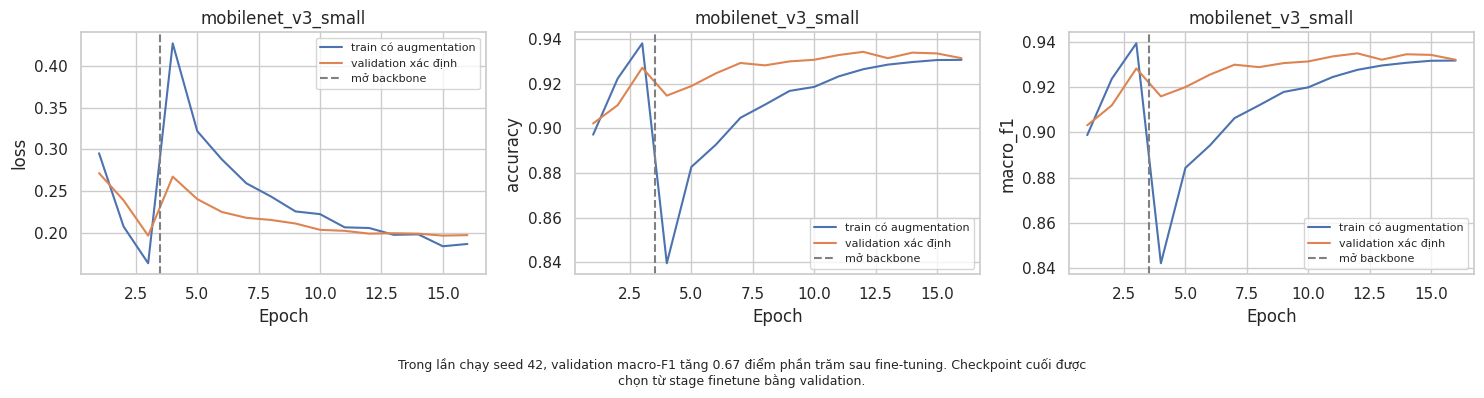

Caption: Trong lần chạy seed 42, validation macro-F1 tăng 0.67 điểm phần trăm sau fine-tuning. Checkpoint cuối được chọn từ stage finetune bằng validation.


In [28]:
show_stage_results(mobilenet_name, mobile_training)


### 7.4. Câu hỏi 2 — đánh giá MobileNet trên ảnh chưa thấy

**Mục đích:** Đo chất lượng checkpoint cuối và phân tích lỗi MobileNet.

**Đầu vào và phụ thuộc:** `mobilenet` đang chứa best.pt và ba split cố định; không cần bất kỳ biến ViT nào.

**Cách hoạt động:** Đánh giá train/val/test bằng transforms xác định, lưu metrics/dự đoán riêng rồi vẽ split metrics, confusion matrix và ảnh lỗi. Registry được cập nhật bằng evaluation của MobileNet.

**Đầu ra:** `mobile_evaluation`, classification report, bảng ba split, biểu đồ và caption từ số liệu test.

**Cách đọc và sử dụng:** Train–validation gap được tính từ cùng chế độ inference. Xem recall mỗi lớp và ô lỗi lớn nhất để biết loại cảnh cần cải thiện; không dùng test này để điều chỉnh epoch/LR trong cùng thí nghiệm.



mobilenet_v3_small: classification report test
              precision  recall  f1-score   support
buildings        0.9258  0.9428    0.9342  437.0000
forest           0.9832  0.9852    0.9842  474.0000
glacier          0.8973  0.8373    0.8662  553.0000
mountain         0.8710  0.8876    0.8792  525.0000
sea              0.9303  0.9686    0.9491  510.0000
street           0.9458  0.9401    0.9429  501.0000
accuracy         0.9243  0.9243    0.9243    0.9243
macro avg        0.9256  0.9269    0.9260 3000.0000
weighted avg     0.9241  0.9243    0.9239 3000.0000

mobilenet_v3_small: checkpoint cuối, preprocessing xác định cho mọi split
        loss  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
train 0.1260    0.9566             0.9576           0.9574        0.9576    0.9574       0.9565
val   0.1992    0.9343             0.9355           0.9347        0.9355    0.9350       0.9341
test  0.2155    0.9243             0.9269           0.9256        0.9

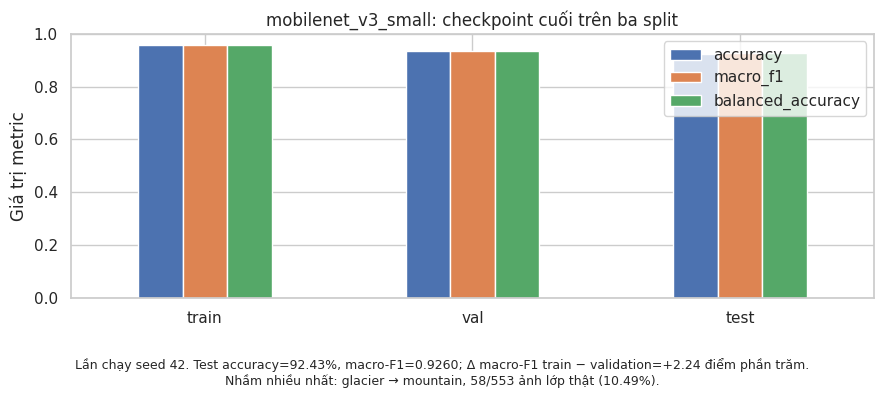

Caption: Lần chạy seed 42. Test accuracy=92.43%, macro-F1=0.9260; Δ macro-F1 train − validation=+2.24 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 58/553 ảnh lớp thật (10.49%).


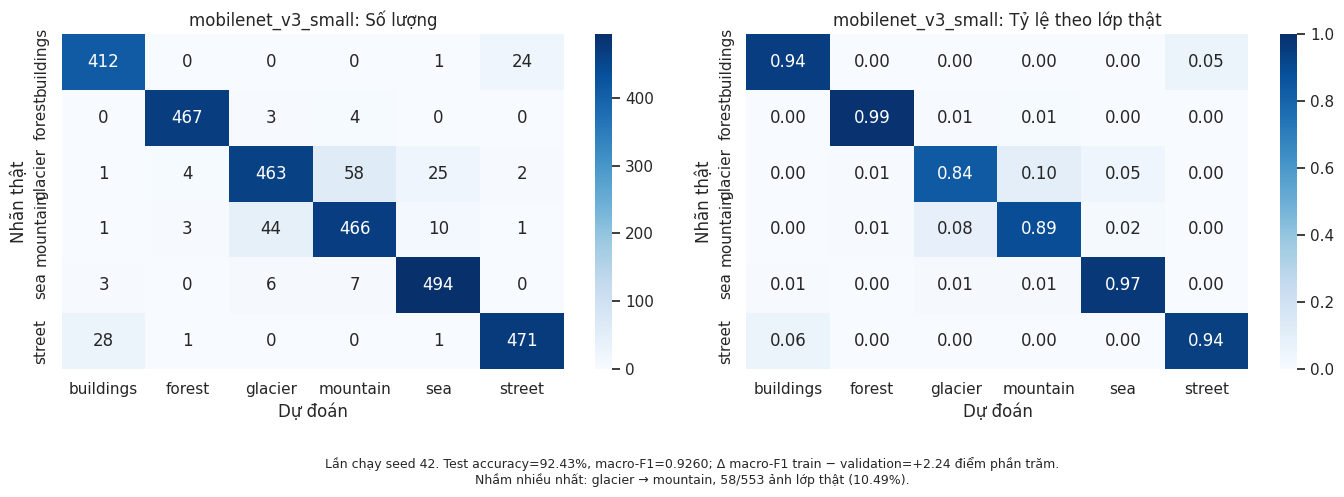

Caption: Lần chạy seed 42. Test accuracy=92.43%, macro-F1=0.9260; Δ macro-F1 train − validation=+2.24 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 58/553 ảnh lớp thật (10.49%).


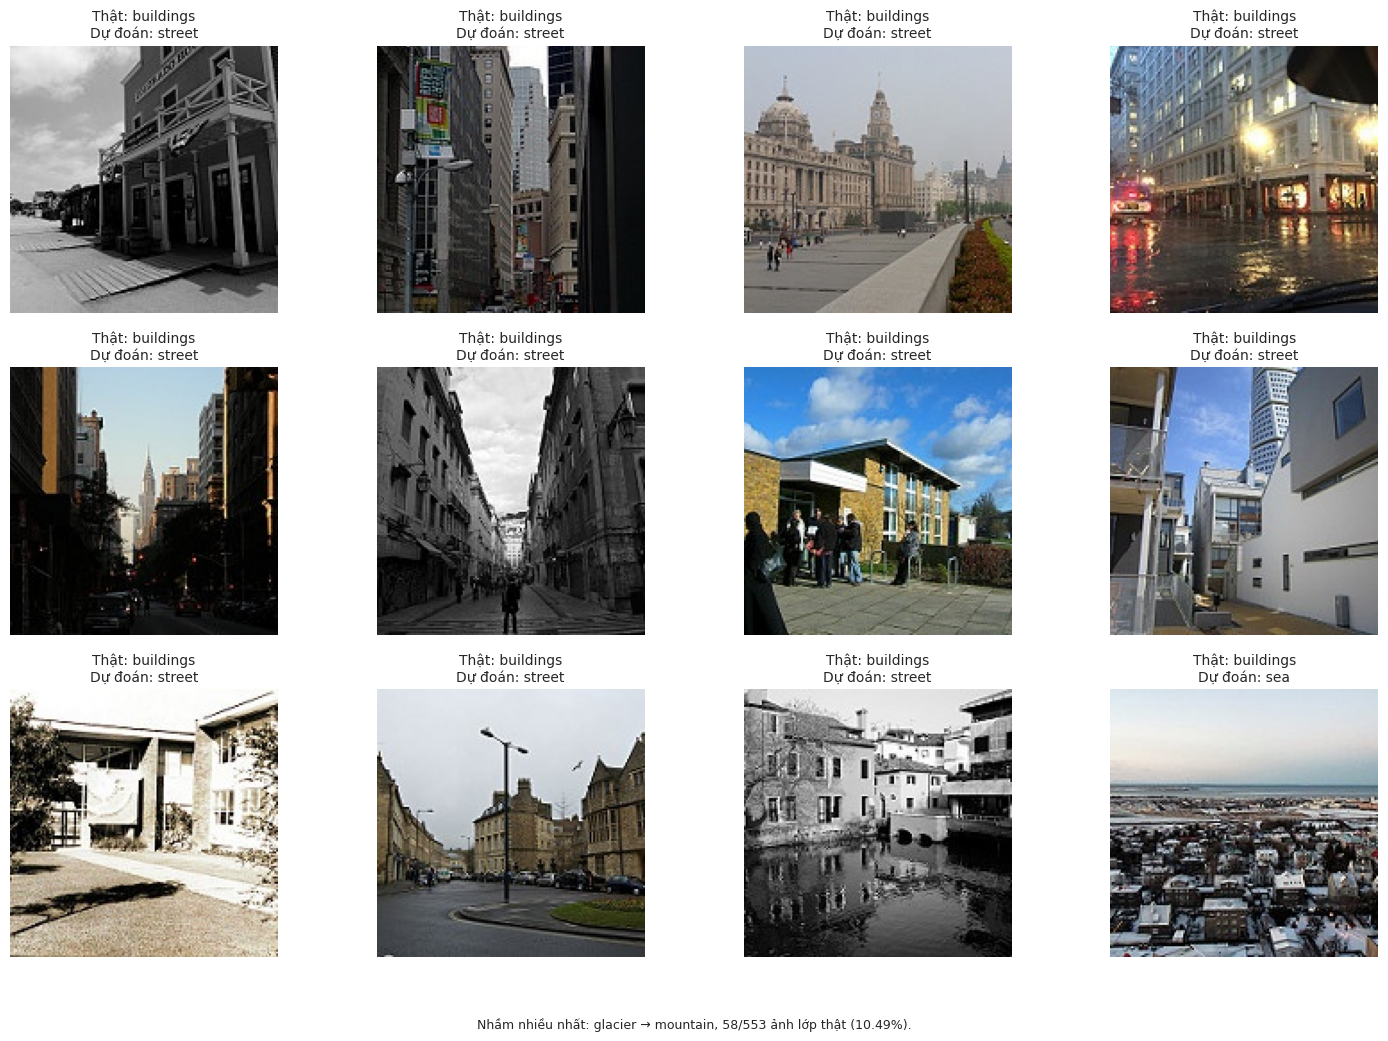

Caption: Nhầm nhiều nhất: glacier → mountain, 58/553 ảnh lớp thật (10.49%).


In [29]:
mobile_evaluation = evaluate_final_model(mobilenet, mobilenet_name)
model_results[mobilenet_name]['evaluation'] = mobile_evaluation
plot_final_results(mobilenet_name, mobile_evaluation)


### 7.5. Kết luận bài thực nghiệm MobileNet

**Mục đích:** Tổng kết riêng MobileNet thành câu hỏi, bằng chứng và câu trả lời.

**Đầu vào và phụ thuộc:** Entry MobileNet trong model_results; evaluation có thể còn trống nếu chủ động bỏ qua cell 7.4.

**Cách hoạt động:** In kết luận bằng print_model_conclusion. Chuyển model về CPU sau phần này để trả VRAM; registry chỉ giữ số liệu và dự đoán.

**Đầu ra:** Kết luận MobileNet trong console; GPU được giải phóng cho bài tiếp theo.

**Cách đọc và sử dụng:** Có thể dừng bài thực nghiệm ở đây và tới phần 9–11. Việc chuyển CPU không thay đổi checkpoint đã lưu hoặc metrics.


In [30]:
print_model_conclusion(mobilenet_name, model_results[mobilenet_name])
mobilenet.to('cpu')
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()



=== mobilenet_v3_small | FULL — seed 42 ===
Số ảnh: train=11204, validation=2802, test=3000.
Câu hỏi 1: Fine-tuning backbone có cải thiện validation so với chỉ train classifier không?
  Head: epoch 3, loss=0.1968, accuracy=92.72%, macro-F1=0.9283.
  Fine-tuning: epoch 9, loss=0.1992, accuracy=93.43%, macro-F1=0.9350.
  Kết luận: Trong lần chạy seed 42, validation macro-F1 tăng 0.67 điểm phần trăm sau fine-tuning. Checkpoint cuối được chọn từ stage finetune bằng validation.
Câu hỏi 2: Checkpoint cuối phân loại test tốt đến đâu, và còn nhầm ở những lớp nào?
  train: loss=0.1260, accuracy=95.66%, macro-F1=0.9574, balanced accuracy=95.76%.
  val: loss=0.1992, accuracy=93.43%, macro-F1=0.9350, balanced accuracy=93.55%.
  test: loss=0.2155, accuracy=92.43%, macro-F1=0.9260, balanced accuracy=92.69%.
  Kết luận: Lần chạy seed 42. Test accuracy=92.43%, macro-F1=0.9260; Δ macro-F1 train − validation=+2.24 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 58/553 ảnh lớp thật (10.49%).
  Khoả

## 8. Bài thực nghiệm B — ViT-B/16

ViT chia ảnh thành các patch rồi dùng self-attention để học tương tác giữa các vùng ảnh.
Với ảnh 224×224 và patch 16×16, có 196 patch và một class token; classifier dùng biểu diễn class token
để dự đoán sáu lớp. Bài này dùng weights `IMAGENET1K_V1`.
Nguồn: [Torchvision ViT-B/16](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html).

Chạy riêng các cell phần 8 sau phần 1–6; không cần chạy phần 7. ViT có nhiều parameter,
nên full training cần GPU và smoke CPU vẫn có thể tốn vài phút.


### 8.1. Khởi tạo ViT-B/16

**Mục đích:** Chuẩn bị riêng mô hình của bài thực nghiệm B.

**Đầu vào và phụ thuộc:** Các phần 1–6, WEIGHTS và cfg; không phụ thuộc biến của MobileNet.

**Cách hoạt động:** Đặt seed, xóa entry ViT cũ, xây model pretrained với head sáu lớp; resume dùng kiến trúc chưa tải weights vì last.pt cung cấp trọng số. Kiểm tra tensor 224×224, patch size và đầu ra classifier.

**Đầu ra:** `vit_name`, `vit`, thông tin patch/token và classifier.

**Cách đọc và sử dụng:** Patch 16 là kích thước vùng ảnh, không phải số lớp. Input 224 phù hợp positional embeddings của bộ weights này; resize ảnh gốc không tạo thêm texture thật.


In [31]:
vit_name = 'vit_b_16'
seed_everything(cfg.seed)
model_results.pop(vit_name, None)
resume_vit = cfg.resume and (ROOT / vit_name / 'last.pt').exists()
vit = build_model(vit_name, pretrained=not resume_vit).to(device)
vit_tensor, vit_label, _ = SceneDataset(splits['val'], WEIGHTS[vit_name].transforms())[0]
assert vit_tensor.shape == (3, 224, 224) and torch.isfinite(vit_tensor).all()
assert vit.heads.head.out_features == NUM_CLASSES
print('ViT-B/16 | input:', tuple(vit_tensor.shape), '| patch:', vit.patch_size,
      '| tokens:', (vit.image_size // vit.patch_size) ** 2 + 1, '| classifier output:', NUM_CLASSES)
print('Weights:', WEIGHTS[vit_name].name, '| resume:', resume_vit)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to intel_cache/torch/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 189MB/s]


ViT-B/16 | input: (3, 224, 224) | patch: 16 | tokens: 197 | classifier output: 6
Weights: IMAGENET1K_V1 | resume: False


### 8.2. Transfer learning ViT-B/16

**Mục đích:** Huấn luyện riêng ViT theo hai giai đoạn với checkpoint validation.

**Đầu vào và phụ thuộc:** `vit` từ cell 8.1 và train/val chung.

**Cách hoạt động:** Gọi train_transfer tường minh cho ViT. Giai đoạn head khóa backbone; fine-tuning bắt đầu từ best_head và mở toàn bộ với LR backbone nhỏ. Đăng ký training summary ViT mà không cần đọc kết quả mô hình khác.

**Đầu ra:** Checkpoint/history riêng trong ROOT/vit_b_16; vit_training và registry ViT.

**Cách đọc và sử dụng:** ViT cần nhiều VRAM hơn mô hình nhỏ; giữ effective batch bằng accumulation khi giảm batch. Test chưa được dùng để chọn checkpoint.


In [32]:
vit_training = train_transfer(vit, vit_name)
model_results[vit_name] = {'training': vit_training, 'evaluation': None}
print('Checkpoint ViT được chọn:', vit_training['selected_stage'])


vit_b_16/head:   0%|          | 0/701 [00:00<?, ?it/s]

vit_b_16 | head 1/3 | loss train=0.2911 | val macro-F1=0.9266


vit_b_16/head:   0%|          | 0/701 [00:00<?, ?it/s]

vit_b_16 | head 2/3 | loss train=0.1917 | val macro-F1=0.9308


vit_b_16/head:   0%|          | 0/701 [00:00<?, ?it/s]

...

vit_b_16 | finetune 9/15 | loss train=0.0037 | val macro-F1=0.9493


vit_b_16/finetune:   0%|          | 0/701 [00:00<?, ?it/s]

vit_b_16 | finetune 10/15 | loss train=0.0034 | val macro-F1=0.9492


vit_b_16/finetune:   0%|          | 0/701 [00:00<?, ?it/s]

vit_b_16 | finetune 11/15 | loss train=0.0024 | val macro-F1=0.9472
Early stopping trong fine-tuning: validation macro-F1 không cải thiện.
Checkpoint ViT được chọn: finetune


### 8.3. Câu hỏi 1 — fine-tuning ViT có giúp validation?

**Mục đích:** Đối chiếu hai giai đoạn trong ViT bằng cùng tiêu chí chọn checkpoint.

**Đầu vào và phụ thuộc:** `vit_training` đã hoàn tất head và fine-tuning.

**Cách hoạt động:** In stage metrics và delta macro-F1 điểm phần trăm; vẽ learning curves với đường đánh dấu mở backbone. Caption được sinh từ kết quả ViT của lần chạy.

**Đầu ra:** Bảng và biểu đồ ViT trả lời câu hỏi 1.

**Cách đọc và sử dụng:** Nếu macro-F1 fine-tuning giảm, checkpoint head vẫn có thể được chọn. Không suy ra hiệu quả fine-tuning từ train loss giảm đơn lẻ; ưu tiên validation.



vit_b_16: đối chiếu hai giai đoạn trong cùng mô hình
   stage  best_epoch  val_loss  val_accuracy  val_macro_f1  selected  delta_macro_f1_pp
    head           3    0.1955        0.9329        0.9339     False             0.0000
finetune           7    0.2354        0.9493        0.9500      True             1.6064
Δ macro-F1 (fine-tuning − head): +1.61 điểm phần trăm


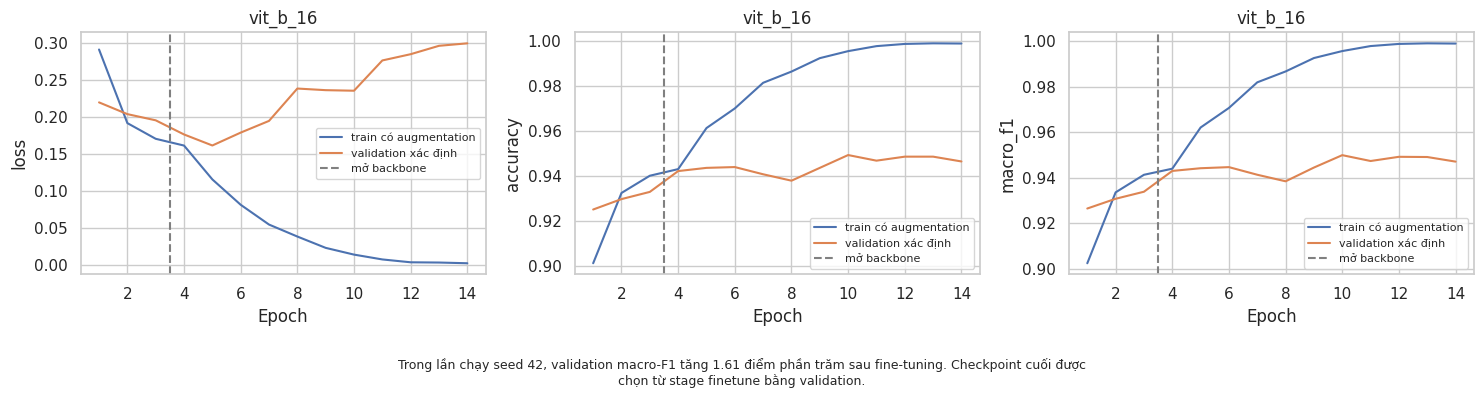

Caption: Trong lần chạy seed 42, validation macro-F1 tăng 1.61 điểm phần trăm sau fine-tuning. Checkpoint cuối được chọn từ stage finetune bằng validation.


In [33]:
show_stage_results(vit_name, vit_training)


### 8.4. Câu hỏi 2 — đánh giá ViT trên ảnh chưa thấy

**Mục đích:** Đo chất lượng cuối và xác định lỗi phân loại của ViT.

**Đầu vào và phụ thuộc:** `vit` với best.pt, ba split và các hàm đánh giá chung.

**Cách hoạt động:** Đánh giá xác định trên train/val/test; lưu artifact riêng ViT; vẽ metrics ba split, confusion matrix và ảnh dự đoán sai. Registry chỉ cập nhật entry ViT.

**Đầu ra:** `vit_evaluation`, báo cáo từng lớp, biểu đồ và caption có accuracy/F1/gap/số lỗi.

**Cách đọc và sử dụng:** Đọc số lỗi cùng support/recall của lớp. Confidence cao có thể vẫn sai; ảnh lỗi là ví dụ cần phân tích, không phải bằng chứng tự động đổi nhãn.



vit_b_16: classification report test
              precision  recall  f1-score   support
buildings        0.9408  0.9451    0.9429  437.0000
forest           1.0000  0.9979    0.9989  474.0000
glacier          0.9231  0.8897    0.9061  553.0000
mountain         0.8942  0.9181    0.9060  525.0000
sea              0.9727  0.9784    0.9756  510.0000
street           0.9463  0.9501    0.9482  501.0000
accuracy         0.9450  0.9450    0.9450    0.9450
macro avg        0.9462  0.9465    0.9463 3000.0000
weighted avg     0.9451  0.9450    0.9450 3000.0000

vit_b_16: checkpoint cuối, preprocessing xác định cho mọi split
        loss  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
train 0.0059    0.9984             0.9984           0.9985        0.9984    0.9984       0.9984
val   0.2354    0.9493             0.9499           0.9503        0.9499    0.9500       0.9493
test  0.2430    0.9450             0.9465           0.9462        0.9465    0.9463       

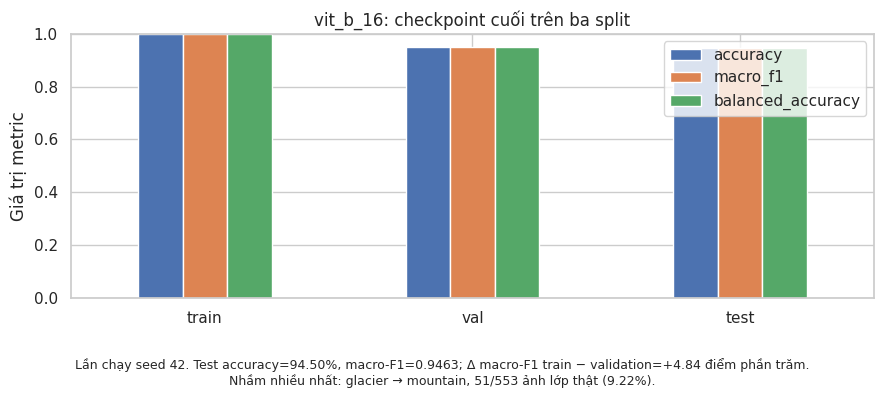

Caption: Lần chạy seed 42. Test accuracy=94.50%, macro-F1=0.9463; Δ macro-F1 train − validation=+4.84 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 51/553 ảnh lớp thật (9.22%).


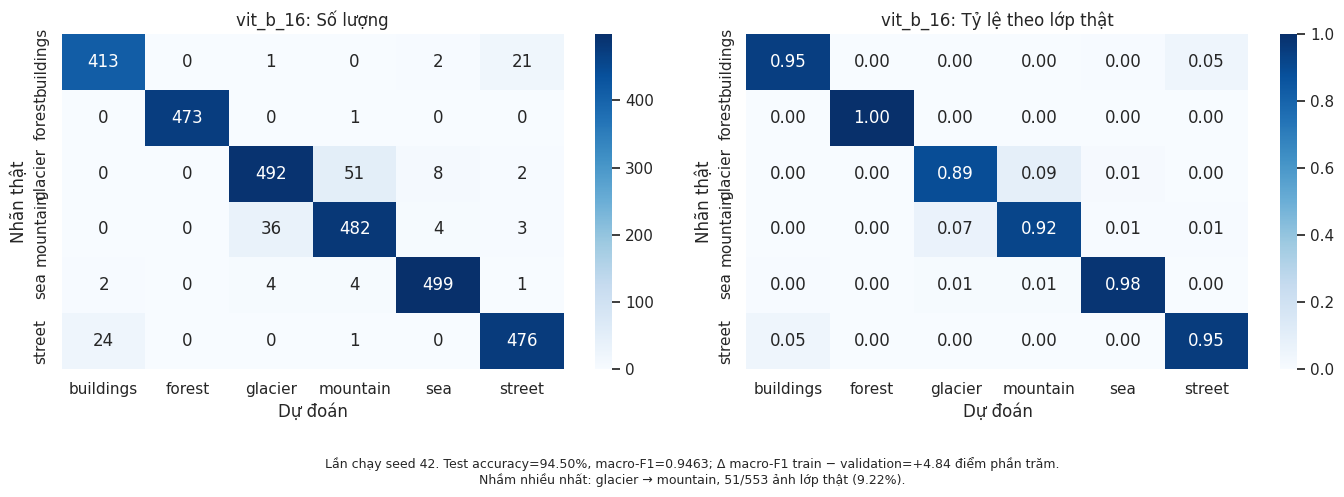

Caption: Lần chạy seed 42. Test accuracy=94.50%, macro-F1=0.9463; Δ macro-F1 train − validation=+4.84 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 51/553 ảnh lớp thật (9.22%).


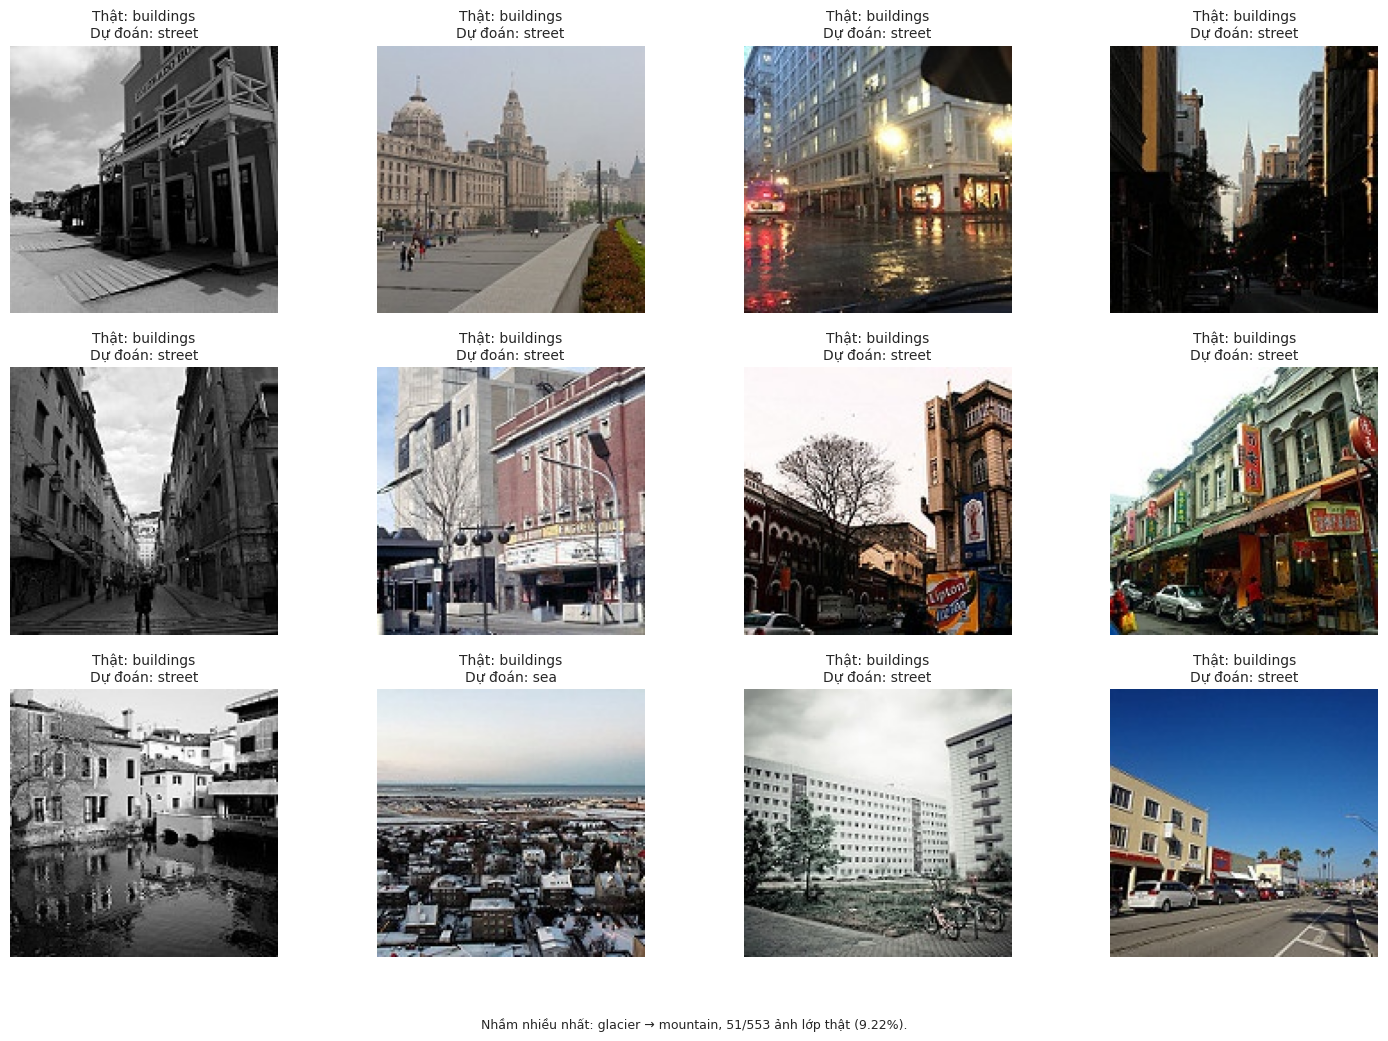

Caption: Nhầm nhiều nhất: glacier → mountain, 51/553 ảnh lớp thật (9.22%).


In [34]:
vit_evaluation = evaluate_final_model(vit, vit_name)
model_results[vit_name]['evaluation'] = vit_evaluation
plot_final_results(vit_name, vit_evaluation)


### 8.5. Kết luận bài thực nghiệm ViT

**Mục đích:** Trả lời hai câu hỏi của riêng ViT bằng số liệu đã thu được.

**Đầu vào và phụ thuộc:** Entry ViT trong registry; không cần kết quả MobileNet.

**Cách hoạt động:** In kết luận và chuyển ViT về CPU để trả VRAM.

**Đầu ra:** Kết luận ViT trong console; mọi checkpoint và metrics của bài vẫn được giữ.

**Cách đọc và sử dụng:** Có thể chạy phần 9–11 ngay sau phần này dù chưa chạy MobileNet. Full một seed cho nhận xét trong lần chạy; smoke chỉ xác nhận pipeline.


In [35]:
print_model_conclusion(vit_name, model_results[vit_name])
vit.to('cpu')
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()



=== vit_b_16 | FULL — seed 42 ===
Số ảnh: train=11204, validation=2802, test=3000.
Câu hỏi 1: Fine-tuning backbone có cải thiện validation so với chỉ train classifier không?
  Head: epoch 3, loss=0.1955, accuracy=93.29%, macro-F1=0.9339.
  Fine-tuning: epoch 7, loss=0.2354, accuracy=94.93%, macro-F1=0.9500.
  Kết luận: Trong lần chạy seed 42, validation macro-F1 tăng 1.61 điểm phần trăm sau fine-tuning. Checkpoint cuối được chọn từ stage finetune bằng validation.
Câu hỏi 2: Checkpoint cuối phân loại test tốt đến đâu, và còn nhầm ở những lớp nào?
  train: loss=0.0059, accuracy=99.84%, macro-F1=0.9984, balanced accuracy=99.84%.
  val: loss=0.2354, accuracy=94.93%, macro-F1=0.9500, balanced accuracy=94.99%.
  test: loss=0.2430, accuracy=94.50%, macro-F1=0.9463, balanced accuracy=94.65%.
  Kết luận: Lần chạy seed 42. Test accuracy=94.50%, macro-F1=0.9463; Δ macro-F1 train − validation=+4.84 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 51/553 ảnh lớp thật (9.22%).
  Khoảng cách tra

## 9. Đọc kết quả như một bài thực nghiệm

Mỗi phần đã đưa ra **câu hỏi → số liệu → caption/kết luận**. Đọc theo thứ tự:

1. Bảng stage: lấy validation macro-F1 của best head và best fine-tuning. Chênh lệch
   `(F1_finetune − F1_head) × 100` là **điểm phần trăm**, không phải phần trăm tăng tương đối.
2. Đường học: xem loss và macro-F1 validation sau khi mở backbone; train trong đường học có augmentation/dropout.
3. Bảng checkpoint cuối: train, validation, test đều được đánh giá với preprocessing xác định.
   Khoảng cách train–validation có ý nghĩa mô tả; cần đọc cùng đường học trước khi suy luận overfitting.
4. Confusion matrix/report: xem recall từng lớp, số ảnh nhầm và tỷ lệ trên số ảnh lớp thật.
5. Ảnh sai: kiểm tra nội dung cảnh, mức mơ hồ và chất lượng ảnh; không tự sửa nhãn chỉ vì model sai hoặc tự tin.

Checkpoint được lựa chọn hoàn toàn bằng validation. Test phục vụ kết luận cuối trong protocol này.
Nếu muốn thử augmentation/LR mới, hãy chọn bằng validation và ghi thí nghiệm riêng; tránh liên tục điều chỉnh theo test.
Registry chỉ chứa mô hình đã chạy trong session này. Các artifact riêng được lưu dưới
`ROOT/mobilenet_v3_small/` hoặc `ROOT/vit_b_16/`; không cần kết quả của phần còn lại để đọc một bài.


## 10. Kiểm tra nhất quán của từng bài đã chạy

**Mục đích:** Xác minh bằng chứng dùng cho kết luận khớp checkpoint, manifest và file dự đoán.

**Đầu vào và phụ thuộc:** model_results, checkpoint trong thư mục riêng và splits; registry có thể rỗng hoặc chỉ một mô hình.

**Cách hoạt động:** Với từng entry, so stage rows với validation metrics trong best checkpoint và đúng dòng history; kiểm tra quy tắc chọn stage/delta. Nếu đã evaluation, đối chiếu test CSV/ID/nhãn/metrics/confusion matrix. Chỉ đọc file và in trạng thái, không xuất báo cáo kiểm chứng.

**Đầu ra:** Thông báo kiểm tra cho từng mô hình đã chạy; assert dừng nếu có sai lệch.

**Cách đọc và sử dụng:** Có thể bỏ qua phần chưa chạy. Nếu chưa có mô hình, cell hướng dẫn chạy phần 7 hoặc 8; không đòi registry phải chứa đủ hai mô hình.


In [36]:
def verify_model_result(model_name, result):
    training = result['training']
    stage_metrics = {}
    for row in training['stage_rows']:
        saved = load_checkpoint(ROOT / model_name / f"best_{row['stage']}.pt", model_name)
        values = saved['validation_metrics']
        stage_metrics[row['stage']] = values
        assert row['best_epoch'] == saved['epoch'] + 1
        for metric in ('loss', 'accuracy', 'macro_f1'):
            assert math.isclose(row[f'val_{metric}'], values[metric], abs_tol=1e-12)
        history_row = next(h for h in training['history'] if h['stage'] == row['stage'] and h['epoch'] == row['best_epoch'])
        assert math.isclose(history_row['val_macro_f1'], row['val_macro_f1'], abs_tol=1e-12)
        del saved
    assert training['selected_stage'] == select_stage(stage_metrics['head'], stage_metrics['finetune'])
    expected_delta = 100 * (stage_metrics['finetune']['macro_f1'] - stage_metrics['head']['macro_f1'])
    assert math.isclose(expected_delta, training['delta_macro_f1_pp'], abs_tol=1e-12)
    if result.get('evaluation') is not None:
        evaluation = result['evaluation']
        predictions = pd.read_csv(ROOT / model_name / 'test_predictions.csv')
        assert predictions.sample_id.tolist() == splits['test'].sample_id.tolist()
        np.testing.assert_array_equal(predictions.label.to_numpy(), splits['test'].label.to_numpy())
        values = metric_values(predictions.label, predictions.prediction)
        for key, value in values.items():
            assert math.isclose(value, evaluation['metrics']['test'][key], abs_tol=1e-12)
        matrix = confusion_matrix(predictions.label, predictions.prediction, labels=LABELS)
        np.testing.assert_array_equal(matrix, evaluation['test_matrix'])
        assert int(matrix.sum()) == len(splits['test'])
    print(f'{model_name}: checkpoint, stage metrics và kết quả hiện có nhất quán.')

if not model_results:
    print('Chưa có mô hình được train trong session này. Chạy phần 7 hoặc 8 trước.')
else:
    for completed_name, completed_result in model_results.items():
        verify_model_result(completed_name, completed_result)


mobilenet_v3_small: checkpoint, stage metrics và kết quả hiện có nhất quán.
vit_b_16: checkpoint, stage metrics và kết quả hiện có nhất quán.


## 11. Kết luận trong console

**Mục đích:** In lại kết quả thực nghiệm của các phần đã chạy mà không tạo file kết luận.

**Đầu vào và phụ thuộc:** Registry model_results trong RAM; không cần cả hai mô hình và không đọc thêm file.

**Cách hoạt động:** Duyệt các entry hiện có, gọi hàm chỉ dùng print(). Mỗi entry có tiêu đề riêng, hai câu hỏi, metrics đối chiếu nội bộ, caption kết luận và giới hạn của lần chạy. Nếu chưa evaluation, chỉ in kết quả stage và báo thiếu test.

**Đầu ra:** Kết luận dạng văn bản trong console/notebook output; không ghi analysis_vi.md hoặc verification.json.

**Cách đọc và sử dụng:** Chạy cell này bất kỳ lúc nào sau một bài. Registry rỗng sẽ có thông báo hướng dẫn; chạy lại cell không thay đổi trọng số, không train lại và không tạo file.


In [37]:
if not model_results:
    print('Chưa có kết quả để kết luận. Hãy chạy phần MobileNetV3 hoặc ViT rồi chạy lại cell này.')
else:
    for completed_name, completed_result in model_results.items():
        print_model_conclusion(completed_name, completed_result)



=== mobilenet_v3_small | FULL — seed 42 ===
Số ảnh: train=11204, validation=2802, test=3000.
Câu hỏi 1: Fine-tuning backbone có cải thiện validation so với chỉ train classifier không?
  Head: epoch 3, loss=0.1968, accuracy=92.72%, macro-F1=0.9283.
  Fine-tuning: epoch 9, loss=0.1992, accuracy=93.43%, macro-F1=0.9350.
  Kết luận: Trong lần chạy seed 42, validation macro-F1 tăng 0.67 điểm phần trăm sau fine-tuning. Checkpoint cuối được chọn từ stage finetune bằng validation.
Câu hỏi 2: Checkpoint cuối phân loại test tốt đến đâu, và còn nhầm ở những lớp nào?
  train: loss=0.1260, accuracy=95.66%, macro-F1=0.9574, balanced accuracy=95.76%.
  val: loss=0.1992, accuracy=93.43%, macro-F1=0.9350, balanced accuracy=93.55%.
  test: loss=0.2155, accuracy=92.43%, macro-F1=0.9260, balanced accuracy=92.69%.
  Kết luận: Lần chạy seed 42. Test accuracy=92.43%, macro-F1=0.9260; Δ macro-F1 train − validation=+2.24 điểm phần trăm. Nhầm nhiều nhất: glacier → mountain, 58/553 ảnh lớp thật (10.49%).
  Khoả